In [ ]:
import gc
import pathlib
import random
from typing import Dict, List, Sequence, Tuple, Union
import uuid

In [ ]:
try:
    import cupy as cp
except ImportError:
    import warnings

    warnings.warn(
        "cupy import failed; falling back to numpy "
        "(GPU engine unavailable)",
        stacklevel=2,
    )
    import numpy as cp

# workaround: iplotx 1.7.x uses importlib.metadata without importing it
import importlib.metadata  # noqa: F401

import downstream.dstream as dstream
import hstrat
import igraph as ig
import iplotx
import marimo as mo
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter, MaxNLocator
import numpy as np
import pandas as pd
from phyloframe import legacy as pfl
import polars as pl
import seaborn as sns
from teeplot import teeplot as tp
from tqdm.auto import tqdm
from watermark import watermark

from pylib import allele_palette, draw_scatter_tree, strain_palette

/usr/local/lib/python3.10/dist-packages/marimo/_runtime/executor.py:138: UserWarning: cupy import failed; falling back to numpy (GPU engine unavailable)
  exec(cell.body, glbls)


In [ ]:
mo.md(
    f"""
```Text
{watermark(
    current_date=True,
    iso8601=True,
    machine=True,
    updated=True,
    python=True,
    iversions=True,
    globals_=globals(),
)}
```
"""
)

```Text
Last updated: 2026-06-25T02:13:00.360015+00:00

Python implementation: CPython
Python version       : 3.10.12
IPython version      : 7.31.1

Compiler    : GCC 11.4.0
OS          : Linux
Release     : 6.8.0-1059-azure
Machine     : x86_64
Processor   : x86_64
CPU cores   : 4
Architecture: 64bit

polars    : 1.40.1
teeplot   : 1.4.2
numpy     : 2.1.2
marimo    : 0.23.2
iplotx    : 1.7.1
pandas    : 2.2.3
downstream: 1.22.0
seaborn   : 0.13.2
igraph    : 0.11.9
hstrat    : 1.25.0
matplotlib: 3.10.7
phyloframe: 0.8.1

```

In [ ]:
# Command-line args for a single founder replicate. Set them after a
# `--` separator, e.g.
#   marimo export ipynb 2026-05-20-founder.py -o out.ipynb -- \
#       --seed 3 --n-sites 8 --pop-size 200000 --n-steps 600
# or `marimo edit 2026-05-20-founder.py -- --seed 3 ...`. Every arg
# has a default, so the notebook also runs with no args at all.
_args = mo.cli_args()
SEED = int(_args.get("seed") or 1)
N_SITES = int(_args.get("n-sites") or 4)
POP_SIZE = int(_args.get("pop-size") or 100_000)
N_STEPS = int(_args.get("n-steps") or 1_200)
POW = float(_args.get("pow") or 1.0)
MUTATION_RATE = float(_args.get("mutation-rate") or 1e-5)
ENGINE = str(_args.get("engine") or "numpy").lower()
if ENGINE not in ("numpy", "cupy"):
    raise ValueError(
        f"engine must be 'numpy' or 'cupy', got {ENGINE!r}",
    )
SKIP_PLOTTING = bool(_args.get("skip-plotting") or False)
print(
    f"args: SEED={SEED} N_SITES={N_SITES} POP_SIZE={POP_SIZE} "
    f"N_STEPS={N_STEPS} POW={POW} MUTATION_RATE={MUTATION_RATE} "
    f"ENGINE={ENGINE} SKIP_PLOTTING={SKIP_PLOTTING}",
)

args: SEED=1 N_SITES=4 POP_SIZE=100000 N_STEPS=1200 POW=1.0 MUTATION_RATE=1e-05 ENGINE=numpy SKIP_PLOTTING=False


In [ ]:
use_cupy = (
    ENGINE == "cupy"
)  # use cupy backend (GPU), otherwise numpy (CPU)
xp = [np, cp][use_cupy]

## Simulation Implementation

This is a **founder** notebook: it runs a *single replicate* of the
allele-based agent-based model (ABM) for one random seed and one
`N_SITES` condition, both chosen on the command line. It is a
single-run, command-line companion to the multi-condition sweep in
`2026-05-06-allele-abm-r-per-strain.py`, and reuses that notebook's
`simulate()` implementation, reconstruction, and figures unchanged.

Every run setting is a CLI argument with a default, so the notebook
runs unconfigured but can be pointed at a specific replicate (pass
args after a `--` separator, see the args cell above):

* `--seed` --- replicate random seed (default `1`).
* `--n-sites` --- number of allele sites / genome bits, which sets
  the strain count `2 ** N_SITES` (default `4`).
* `--pop-size` --- host population size (default `100_000`).
* `--n-steps` --- number of simulation updates / steps to run
  (default `1_200`).
* `--engine` --- compute backend, `numpy` (CPU) or `cupy` (GPU)
  (default `numpy`).
* `--pow` --- susceptibility-product exponent (default `1.0`).
* `--mutation-rate` --- per-genome per-step mutation rate, spread
  across the `N_SITES` bits (default `1e-5`).
* `--skip-plotting` --- skip figure rendering (default `False`).

Each genome bit is an allele; a circulating strain's **Hamming
weight** is its number of `1` bits, i.e. the number of mutations
separating it from the founder (wildtype, all-zero) strain seeded at
step 0. The per-step Hamming-weight distribution of circulating
strains is logged **as a raw case count** --- the number of
currently-infected hosts at each Hamming weight --- in the
`n_cases` column of the `hw` dataframe, alongside the inherited
population-fraction `count` column. The `strain` dataframe likewise
gets a per-genome raw case count `n_cases` (number of currently-
infected hosts carrying each genome) plus `n_new_infections` (new
infections caused by each genome this step, pre-mutation). Every
output dataframe is also stamped with the simulation parameters as
constant-valued columns and a `replicate_uid` generated with the
standard-library `uuid` module, so rows from a run are self-
describing and uniquely identifiable.

`update_recoveries()` is patched to **prevent extinction**: if a
step's recovery roll would clear the last remaining infection, one
of the would-be-recovered hosts is exempted so the run never drops
to zero circulating cases. The rescued host continues as an
ordinary infected host into the next step without gaining immunity
against its current strain.

When the strain count `2 ** N_SITES` exceeds 16, the per-strain
figures (strain curves, R-curves, strain summary, strain graph) are
skipped --- one line/node per strain is unreadable, and the dense
`(POP_SIZE, n_strains, N_SITES)` susceptibility tensor used for
expected-R is gated off above a memory cap. The Hamming-weight
stackplot and Hamming-distance density heatmap aggregate only
`N_SITES + 1` bins, so they continue to render at large `N_SITES`.

The inherited "r-curves" figure is a multi-row stack with the
*expected* per-strain reproduction number on the very top row by
itself, and the *actual* per-strain reproduction number on
subsequent rows at increasing rolling-mean windows (unsmoothed
first). Both per-step rates are scaled by the discrete-time R0
multiplier
`(1 - RECOVERY_RATE) / RECOVERY_RATE` so the plotted values are
the expected total infections caused by a single primary (an
`R0`-like quantity) rather than the per-step rate, and `R = 1`
is drawn as the epidemic-threshold reference line. The factor
is `(1 - p) / p` rather than `1 / p` because
`update_recoveries` runs after `transmit_infection` within the
same step, so a primary newly infected in step `t` faces an
immediate recovery check before participating as a source at
step `t+1`; the expected number of future transmit-as-source
steps is `sum_{k=1}^inf (1 - p)^k = (1 - p) / p` (off-by-one if
you forget the within-step recovery).

* `R_actual(t, s) = new_infections(s, t) /
  n_with_strain(s, t) * (1 - RECOVERY_RATE) / RECOVERY_RATE` --
  new strain-`s` infections caused per current strain-`s`
  infected per step, multiplied by the R0 multiplier, computed
  from instrumentation logged inside `simulate()`.
  `new_infections` is captured pre-mutation in
  `update_simulation()` so the strain label reflects the strain
  that actually transmitted, not its post-mutation descendant.

* `R_expected(t, s) = R_expected_per_step(s, t) *
  (1 - RECOVERY_RATE) / RECOVERY_RATE`, where
  `R_expected_per_step(s, t)` is the average over the population
  of the probability that strain `s` infects a randomly-sampled
  individual on a single contact in one step. Currently-infected
  hosts contribute zero since they cannot be re-infected --- the
  `(host_statuses == 0)` mask zeros out their per-host
  susceptibilities before averaging over the full `POP_SIZE`, so
  the mean already accounts for the susceptible-only fraction.
  The per-step quantity is logged as `strain_df["expected_R"]`
  alongside `count` and `new_infections`; multiplying by the
  R0 multiplier gives the analog of `R0`.

Phylogeny estimation still uses *hereditary stratigraphic surface*
annotations (see https://hstrat.rtfd.io). Each infected host carries
a `dstream_S=64`-site, 1-bit "hybrid" surface; the donor surface
state is copied to the recipient on transmission (the ABM analogue
of `CloneDescendant`). Per-step Hamming-weight prevalence and
per-strain prevalence are both logged as long-form dataframes (one
row per `(Step, hw)` and `(Step, strain)`).

The vectorized deposit pattern is adapted from
https://github.com/mmore500/hstrat-synthesis (see `pylib/track_ca.py`).

In [ ]:
def simulate(
    N_SITES: int = 2,
    POP_SIZE: int = 1_000_000,
    CONTACT_RATE: float = 0.3,
    RECOVERY_RATE: float = 0.1,
    MUTATION_RATE: Union[float, Sequence[float]] = 1e-4,
    WANING_RATE: float = 0.02,
    IMMUNE_STRENGTH: float = 0.9,
    N_STEPS: int = 1_000,
    SEED_COUNT: int = 10,
    within_host_b: float = 0.2,
    within_host_t: float = 25.0,
    seed: int = 1,
    MUTATOR_HOSTS_N: int = 0,
    MUTATOR_HOSTS_MX: float = 1.0,
    MUTATION_THRESHOLD: float = 0.0,
    IMMUNITY_CEILING: float = 1.0,
    IMMUNITY_FLOOR: float = 0.0,
    track_phylogeny: bool = False,
    DSTREAM_S: int = 64,
    DSTREAM_ALGO=None,
    N_SAMPLE: int = 2000,
    pow: float = 1.0,
) -> Union[
    Tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame],
    Tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame, pd.DataFrame],
]:
    random.seed(seed)
    np.random.seed(seed)
    xp.random.seed(seed)

    if DSTREAM_ALGO is None:
        DSTREAM_ALGO = dstream.hybrid_0_steady_1_tilted_2_algo

    MUTATION_RATE = xp.asarray(MUTATION_RATE, dtype=xp.float32)

    # Pick the smallest unsigned int dtype that holds `N_SITES` bits.
    # 16/32/64-site sweeps round-trip through uint16/uint32/uint64
    # without truncation; >64 would need a custom multi-word genome.
    if N_SITES > 64:
        raise NotImplementedError(
            "current data types support only up to 64 sites",
        )
    elif N_SITES > 32:
        genome_dtype = xp.uint64
    elif N_SITES > 16:
        genome_dtype = xp.uint32
    else:
        genome_dtype = xp.uint16

    def initialize_pop() -> (
        Tuple[xp.ndarray, xp.ndarray, xp.ndarray, xp.ndarray]
    ):
        """Initialize population statuses, genomes, and immune history."""
        pathogen_genomes = xp.zeros(shape=POP_SIZE, dtype=genome_dtype)
        host_immunities = xp.full(
            shape=(POP_SIZE, 2 * N_SITES),
            fill_value=0.0,
            dtype=xp.float32,
        )
        host_statuses = xp.full(
            shape=POP_SIZE, fill_value=0, dtype=xp.uint8
        )
        pathogen_markers = xp.random.randint(
            low=0,
            high=2**63,
            size=POP_SIZE,
            dtype=xp.int64,
        ).astype(xp.uint64)
        pathogen_markers |= xp.random.randint(
            low=0,
            high=2,
            size=POP_SIZE,
            dtype=xp.uint64,
        ) << xp.uint64(63)
        return (
            host_statuses,
            pathogen_genomes,
            host_immunities,
            pathogen_markers,
        )

    def infect_initial(
        host_statuses: xp.ndarray,
        pathogen_genomes: xp.ndarray,
    ) -> Tuple[xp.ndarray, xp.ndarray]:
        """Seed the initial infection wave with the starting strain."""
        seeded_indices = xp.random.choice(
            POP_SIZE, size=SEED_COUNT, replace=False
        )
        host_statuses[seeded_indices] = 1
        pathogen_genomes[seeded_indices] = 0  # wildtype
        return host_statuses, pathogen_genomes

    def calc_infection_probabilities(
        host_immunities: xp.ndarray,
        pathogen_genomes: xp.ndarray,
    ) -> xp.ndarray:
        host_susceptibilities = xp.reshape(
            1.0 - (IMMUNE_STRENGTH * host_immunities),
            (POP_SIZE, 2 * N_SITES),
        )

        pathogen_bits = (
            pathogen_genomes[:, None] >> xp.arange(N_SITES, dtype=xp.uint8)
        ) & 1
        pathogen_alleles = (
            pathogen_bits[:, :, None] == xp.array([0, 1])
        ).reshape(-1, 2 * N_SITES)

        active_susc = xp.where(
            pathogen_alleles, host_susceptibilities, 1.0
        )
        res = xp.prod(active_susc, axis=1)
        assert res.shape == (POP_SIZE,)
        return xp.pow(res, pow)

    if MUTATION_RATE.size == 1:

        def calc_mutation_probabilities(
            host_immunities: xp.ndarray,
            pathogen_genomes: xp.ndarray,
        ) -> xp.ndarray:
            pathogen_bits = (
                pathogen_genomes[:, None]
                >> xp.arange(N_SITES, dtype=xp.uint8)
            ) & 1

            imm_reshaped = xp.reshape(host_immunities, (-1, N_SITES, 2))

            idx_curr = pathogen_bits[:, :, None]
            idx_opp = 1 - idx_curr

            imm_curr = xp.take_along_axis(
                imm_reshaped, idx_curr, axis=2
            ).squeeze(axis=2)
            imm_opp = xp.take_along_axis(
                imm_reshaped, idx_opp, axis=2
            ).squeeze(axis=2)

            host_immunity_deltas = imm_curr - imm_opp

            b_values = 1.0 + within_host_b * host_immunity_deltas
            b_values = xp.where(
                xp.abs(b_values - 1.0) < 1e-7, 1.000001, b_values
            )

            return (MUTATION_RATE / (b_values - 1.0)) * (
                xp.exp((b_values - 1.0) * within_host_t) - 1.0
            )

    else:

        def calc_mutation_probabilities(
            host_immunities: xp.ndarray,
            pathogen_genomes: xp.ndarray,
        ) -> xp.ndarray:
            n_infected = host_immunities.shape[0]
            return (
                xp.ones((n_infected, 1), dtype=MUTATION_RATE.dtype)
                * MUTATION_RATE
            )

    def update_waning(host_immunities: xp.ndarray) -> xp.ndarray:
        host_immunities *= 1.0 - WANING_RATE
        host_immunities[host_immunities > 0] = xp.clip(
            host_immunities[host_immunities > 0],
            IMMUNITY_FLOOR,
            IMMUNITY_CEILING,
        )
        return host_immunities

    def update_recoveries(
        host_statuses: xp.ndarray,
        host_immunities: xp.ndarray,
        pathogen_genomes: xp.ndarray,
    ) -> Tuple[xp.ndarray, xp.ndarray]:
        recovered_mask = (host_statuses >= 1) * xp.random.rand(
            POP_SIZE
        ) > 1 - RECOVERY_RATE

        # Prevent extinction: if every currently-infected host would
        # recover this step, exempt one of the would-be-recovered
        # hosts so at least one infection always remains. The
        # rescued host's `recovered_mask` entry is cleared, so its
        # genome's per-site immunities aren't bumped to 1.0 and its
        # `host_statuses` stays positive --- it continues as an
        # ordinary infected host into the next step.
        infected_pre = host_statuses >= 1
        if bool(xp.any(infected_pre)) and not bool(
            xp.any(infected_pre & ~recovered_mask)
        ):
            rescue_idx = int(
                xp.where(infected_pre & recovered_mask)[0][0],
            )
            recovered_mask[rescue_idx] = False

        pathogen_bits = (
            pathogen_genomes[:, None] >> xp.arange(N_SITES, dtype=xp.uint8)
        ) & 1
        pathogen_alleles = (
            pathogen_bits[:, :, None] == xp.array([0, 1])
        ).reshape(-1, 2 * N_SITES)

        assert np.all(
            pathogen_alleles[recovered_mask].sum(axis=1) == N_SITES
        )

        host_immunities[
            pathogen_alleles.astype(bool) & recovered_mask[:, None]
        ] = 1.0

        host_statuses += (host_statuses > 0).astype(xp.uint8)
        host_statuses[recovered_mask] = 0

        return host_statuses, host_immunities

    def transmit_infection(
        host_statuses: xp.ndarray,
        pathogen_genomes: xp.ndarray,
        host_immunities: xp.ndarray,
        pathogen_markers: xp.ndarray,
    ) -> Tuple[xp.ndarray, xp.ndarray, xp.ndarray, xp.ndarray]:
        contacts = xp.random.randint(
            low=0, high=POP_SIZE, size=POP_SIZE, dtype=xp.uint32
        )
        inf_probs = (
            calc_infection_probabilities(
                host_immunities, pathogen_genomes[contacts]
            )
            * (host_statuses == 0)
            * (host_statuses[contacts] > 0)
            * CONTACT_RATE
        )

        new_infections = xp.random.rand(POP_SIZE) < inf_probs
        host_statuses[new_infections] = 1
        pathogen_genomes[new_infections] = pathogen_genomes[contacts][
            new_infections
        ]
        pathogen_markers[new_infections] = pathogen_markers[contacts][
            new_infections
        ]

        return (
            host_statuses,
            pathogen_genomes,
            pathogen_markers,
            new_infections,
        )

    def apply_mutations(
        pathogen_genomes: xp.ndarray,
        host_statuses: xp.ndarray,
    ) -> xp.ndarray:
        mutation_mask = (host_statuses == 1).astype(bool)

        mprobs = calc_mutation_probabilities(
            host_immunities[mutation_mask],
            pathogen_genomes[mutation_mask],
        )
        mutator_n = host_statuses[:MUTATOR_HOSTS_N].sum()
        mprobs[:mutator_n] = xp.minimum(
            mprobs[:mutator_n] * MUTATOR_HOSTS_MX, 1.0
        )

        mprobs[mprobs < MUTATION_THRESHOLD] = 0.0

        for s in range(N_SITES):
            mutation_occurs = (
                xp.random.rand(mprobs.shape[0]) < mprobs[:, s]
            ).astype(genome_dtype)
            pathogen_genomes[mutation_mask] ^= (
                mutation_occurs << s
            ).astype(genome_dtype)

        return pathogen_genomes

    def deposit_strata(
        pathogen_markers: xp.ndarray,
        t: int,
    ) -> xp.ndarray:
        site = DSTREAM_ALGO.assign_storage_site(DSTREAM_S, t + DSTREAM_S)
        if site is None:
            return pathogen_markers
        new_bits = xp.random.randint(
            0,
            2,
            size=POP_SIZE,
            dtype=xp.uint64,
        )
        pathogen_markers ^= new_bits << np.uint64(63 - site)
        return pathogen_markers

    def update_simulation(
        host_statuses: xp.ndarray,
        pathogen_genomes: xp.ndarray,
        host_immunities: xp.ndarray,
        pathogen_markers: xp.ndarray,
        t: int,
    ) -> Tuple[xp.ndarray, xp.ndarray, xp.ndarray, xp.ndarray, xp.ndarray]:
        (
            host_statuses,
            pathogen_genomes,
            pathogen_markers,
            new_infections,
        ) = transmit_infection(
            host_statuses,
            pathogen_genomes,
            host_immunities,
            pathogen_markers,
        )
        new_strain_genomes = pathogen_genomes[new_infections].copy()
        pathogen_genomes = apply_mutations(pathogen_genomes, host_statuses)
        host_statuses, host_immunities = update_recoveries(
            host_statuses, host_immunities, pathogen_genomes
        )
        host_immunities = update_waning(host_immunities)
        pathogen_markers = deposit_strata(pathogen_markers, t)

        return (
            host_statuses,
            pathogen_genomes,
            host_immunities,
            pathogen_markers,
            new_strain_genomes,
        )

    (
        host_statuses,
        pathogen_genomes,
        host_immunities,
        pathogen_markers,
    ) = initialize_pop()
    host_statuses, pathogen_genomes = infect_initial(
        host_statuses, pathogen_genomes
    )
    data_log: List[Dict[str, float]] = []
    hw_log: List[Dict[str, float]] = []
    strain_log: List[Dict[str, float]] = []
    n_strains = 1 << N_SITES

    # Precomputed per-(strain, site) susceptibility-column indices
    # (a strain's allele bit at each site selects which of the two
    # per-allele susc entries enters the per-strain product).
    _strain_idx = xp.arange(n_strains, dtype=xp.int64)
    _site_idx = xp.arange(N_SITES, dtype=xp.int64)
    _strain_bits = (_strain_idx[:, None] >> _site_idx[None, :]) & 1
    _strain_cols = (2 * _site_idx[None, :] + _strain_bits).astype(
        xp.int64,
    )

    for t in tqdm(range(N_STEPS), mininterval=20.0):
        (
            host_statuses,
            pathogen_genomes,
            host_immunities,
            pathogen_markers,
            new_strain_genomes,
        ) = update_simulation(
            host_statuses,
            pathogen_genomes,
            host_immunities,
            pathogen_markers,
            t,
        )

        inf_mask = host_statuses > 0
        hw_prevalences: List[float] = [0.0] * (N_SITES + 1)
        # Raw case counts (number of currently-infected hosts) at
        # each Hamming weight, i.e. the Hamming-weight prevalence
        # expressed as a count of cases rather than a population
        # fraction.
        hw_case_counts: List[int] = [0] * (N_SITES + 1)
        strain_prevalences: List[float] = [0.0] * n_strains
        # Raw per-genome infection counts (currently-infected hosts
        # carrying each strain), recorded alongside the population-
        # fraction `count` so the strain dataframe carries the
        # absolute per-genome case load.
        strain_case_counts: List[int] = [0] * n_strains

        if xp.any(inf_mask):
            infected_bits = (
                pathogen_genomes[inf_mask, None]
                >> xp.arange(N_SITES, dtype=xp.uint8)
            ) & 1
            hw_per_host = infected_bits.sum(axis=1).astype(xp.int64)
            hw_counts_arr = xp.bincount(hw_per_host, minlength=N_SITES + 1)
            _hw_counts_list = hw_counts_arr.tolist()
            hw_case_counts = [int(c) for c in _hw_counts_list]
            hw_prevalences = [float(c) / POP_SIZE for c in _hw_counts_list]

            strain_per_host = pathogen_genomes[inf_mask].astype(xp.int64)
            strain_counts_arr = xp.bincount(
                strain_per_host, minlength=n_strains
            )
            _strain_counts_list = strain_counts_arr.tolist()
            strain_case_counts = [int(c) for c in _strain_counts_list]
            strain_prevalences = [
                float(c) / POP_SIZE for c in _strain_counts_list
            ]

        # Per-strain new infections this step (raw count of newly-
        # infected hosts and the equivalent population fraction).
        # Captured pre-mutation in update_simulation so the strain
        # label is the strain that actually transmitted.
        new_strain_n_cases: List[int] = [0] * n_strains
        if new_strain_genomes.size > 0:
            new_strain_counts_arr = xp.bincount(
                new_strain_genomes.astype(xp.int64),
                minlength=n_strains,
            )
            _new_strain_list = new_strain_counts_arr.tolist()
            new_strain_n_cases = [int(c) for c in _new_strain_list]
            new_strain_counts = [
                float(c) / POP_SIZE for c in _new_strain_list
            ]
        else:
            new_strain_counts = [0.0] * n_strains

        # Per-strain expected R per current infected per step:
        # average over the population of P(strain s infects a random
        # individual in one step). Currently-infected hosts
        # contribute 0 since they cannot be re-infected --- the
        # `(host_statuses == 0)` mask zeros out their per-host
        # entries before averaging over the full POP_SIZE, so the
        # mean already accounts for the susceptible-only fraction.
        # Multiplying by n(s, t) gives the expected number of new
        # strain-s infections per step. The dense
        # (POP_SIZE, n_strains, N_SITES) tensor is skipped when it
        # would exceed the cap (e.g. N_SITES >= 16 sweeps); the
        # r-curves plot is also skipped for those conditions, so
        # the all-zero column is never consumed downstream.
        _expected_R_tensor_bytes = POP_SIZE * n_strains * N_SITES * 4
        if _expected_R_tensor_bytes <= 2 * 1024**3:
            host_susc_2d = (
                1.0 - (IMMUNE_STRENGTH * host_immunities)
            ).reshape(POP_SIZE, 2 * N_SITES)
            strain_susc_per_host = host_susc_2d[:, _strain_cols].prod(
                axis=2,
            )
            strain_susc_per_host = xp.power(strain_susc_per_host, pow)
            strain_susc_per_host = (
                strain_susc_per_host * (host_statuses == 0)[:, None]
            )
            expected_R_per_strain = (
                strain_susc_per_host.mean(axis=0) * CONTACT_RATE
            )
            expected_R_list = [
                float(x) for x in expected_R_per_strain.tolist()
            ]
        else:
            expected_R_list = [0.0] * n_strains

        for w, count in enumerate(hw_prevalences):
            hw_log.append(
                {
                    "Step": t,
                    "Seed": seed,
                    "hw": w,
                    "count": count,
                    "n_cases": hw_case_counts[w],
                }
            )

        for s, count in enumerate(strain_prevalences):
            strain_log.append(
                {
                    "Step": t,
                    "Seed": seed,
                    "strain": s,
                    "count": count,
                    "n_cases": strain_case_counts[s],
                    "new_infections": new_strain_counts[s],
                    "n_new_infections": new_strain_n_cases[s],
                    "expected_R": expected_R_list[s],
                }
            )

        avg_susc = xp.mean(
            (1.0 - (IMMUNE_STRENGTH * host_immunities))
            * (host_statuses == 0)[:, None],
            axis=0,
        )

        immunity_dict = {}
        for i in range(2 * N_SITES):
            site = i // 2
            bit = i % 2
            immunity_dict[f"Susc_S{site}_B{bit}"] = float(avg_susc[i])

        log_entry = {
            "Step": t,
            "Seed": seed,
            "Total_Infected": float(xp.sum(inf_mask)) / POP_SIZE,
        }
        log_entry.update(immunity_dict)
        data_log.append(log_entry)

    df = pd.DataFrame(data_log).fillna(0).copy()
    hw_df = pd.DataFrame(hw_log)
    strain_df = pd.DataFrame(strain_log)
    if not track_phylogeny:
        return df, hw_df, strain_df

    algo_name = f"dstream.{DSTREAM_ALGO.__name__}"
    S = DSTREAM_S
    T_bitwidth = 32
    bitwidth = 1
    bytes_per_T = T_bitwidth // 8
    bytes_per_storage = S * bitwidth // 8
    bytes_per_row = bytes_per_T + bytes_per_storage
    empty_records = pd.DataFrame(
        {
            "data_hex": pd.Series([], dtype=str),
            "dstream_algo": pd.Series([], dtype=str),
            "dstream_storage_bitoffset": pd.Series([], dtype="int64"),
            "dstream_storage_bitwidth": pd.Series([], dtype="int64"),
            "dstream_T_bitoffset": pd.Series([], dtype="int64"),
            "dstream_T_bitwidth": pd.Series([], dtype="int64"),
            "dstream_S": pd.Series([], dtype="int64"),
            "extant": pd.Series([], dtype=bool),
            "snapshot_step": pd.Series([], dtype="int64"),
            "genome": pd.Series([], dtype="int64"),
            "taxon_id": pd.Series([], dtype="int64"),
        },
    )
    infected_idx = xp.where(host_statuses > 0)[0]
    n_inf = int(infected_idx.size)
    if n_inf == 0:
        return df, hw_df, strain_df, empty_records

    n_sample = min(N_SAMPLE, n_inf)
    sampled = (
        xp.random.choice(infected_idx, size=n_sample, replace=False)
        if n_sample < n_inf
        else infected_idx
    )

    # CUPY SUPPORT: Transfer to host if using GPU
    _to_np = (lambda a: np.asarray(a)) if xp is np else (lambda a: a.get())
    sampled_markers = _to_np(pathogen_markers[sampled])
    sampled_genomes = _to_np(pathogen_genomes[sampled])
    # Rank includes implicit predeposits
    sampled_steps = np.full(n_sample, N_STEPS + DSTREAM_S, dtype=np.uint32)
    sampled_taxon_ids = np.arange(n_sample, dtype=np.int64)

    T_bytes_hex = sampled_steps.astype(">u4").tobytes().hex()
    marker_bytes_hex = sampled_markers.astype(">u8").tobytes().hex()
    data_hex = [
        (
            T_bytes_hex[i * bytes_per_T * 2 : (i + 1) * bytes_per_T * 2]
            + marker_bytes_hex[
                i * bytes_per_storage * 2 : (i + 1) * bytes_per_storage * 2
            ]
        )
        for i in range(n_sample)
    ]

    records_df = pd.DataFrame(
        {
            "data_hex": data_hex,
            "dstream_algo": algo_name,
            "dstream_storage_bitoffset": bytes_per_T * 8,
            "dstream_storage_bitwidth": bytes_per_storage * 8,
            "dstream_T_bitoffset": 0,
            "dstream_T_bitwidth": T_bitwidth,
            "dstream_S": S,
            "extant": True,
            "snapshot_step": sampled_steps.astype(np.int64),
            "genome": sampled_genomes.astype(np.int64),
            "taxon_id": sampled_taxon_ids,
        }
    )
    assert all(len(h) == bytes_per_row * 2 for h in data_hex), (
        f"hex length mismatch (expected {bytes_per_row * 2}, "
        f"got {set(len(h) for h in data_hex)})"
    )
    del data_hex, T_bytes_hex, marker_bytes_hex
    gc.collect()
    return df, hw_df, strain_df, records_df

## Surface-Annotation Reconstruction

Given the snapshot records emitted by `simulate(..., track_phylogeny=
True)`, run `hstrat.dataframe.surface_unpack_reconstruct` followed by
`hstrat.dataframe.surface_postprocess_trie` to estimate the phylogenetic
tree. We use `AssignOriginTimeNodeRankTriePostprocessor(t0="dstream_S")`
so that origin times line up with simulation step numbers.

In [ ]:
def reconstruct_phylogeny(
    records_df: pd.DataFrame,
) -> pd.DataFrame:
    in_df = pl.from_pandas(records_df)
    post = hstrat.dataframe.surface_build_tree(
        in_df,
        trie_postprocessor=(
            hstrat.phylogenetic_inference.AssignOriginTimeNodeRankTriePostprocessor(
                t0="dstream_S",
            )
        ),
    ).to_pandas()
    gc.collect()
    for col in ("id", "ancestor_id"):
        if col in post.columns:
            post[col] = post[col].astype("int64")
    post["extant"] = post["extant"].fillna(False).astype(bool)
    for col in ("snapshot_step", "genome", "origin_time"):
        if col in post.columns:
            post[col] = pd.to_numeric(post[col], errors="coerce")
    return post

## Surface-Reconstructed Phylogeny

Sweep `N_SITES` over a few values and render the surface-reconstructed
phylogeny next to the absolute-prevalence and Hamming-weight stackplots.

In [ ]:
def make_phylogeny_plot(
    N_SITES: int,
    phylo_df,
    hw_df,
    phylogeny_df,
    max_tips: int = 10_000,
    seed: int = 0,
    palette: str = "rocket_r",
    teeplot_outattrs: dict = {},
) -> None:
    pruned_df = (
        pfl.alifestd_downsample_tips_uniform_asexual(
            phylogeny_df,
            n_downsample=max_tips,
            seed=0,
        )
        .pipe(pfl.alifestd_add_global_root, root_attrs={"origin_time": 0})
        .pipe(pfl.alifestd_collapse_unifurcations)
        .pipe(pfl.alifestd_try_add_ancestor_list_col)
        .pipe(pfl.alifestd_ladderize_asexual)
        .pipe(pfl.alifestd_assign_contiguous_ids)
    )
    assert pfl.alifestd_validate(pruned_df)
    print(f"  downsampled tree: {len(pruned_df)} nodes")
    print(f"  leaf count: {pfl.alifestd_count_leaf_nodes(pruned_df)}")

    pruned_df = pruned_df.assign(
        hw=pruned_df["genome"].map(
            lambda g: None if pd.isna(g) else bin(int(g)).count("1"),
        ),
    )
    pruned_df = pruned_df.assign(
        hw_label=pruned_df["hw"].map(
            lambda w: None if pd.isna(w) else f"HW {int(w)}"
        ),
    )

    hw_values = list(range(N_SITES + 1))
    hw_palette = sns.color_palette(palette, len(hw_values))

    present_hw = sorted(int(w) for w in hw_df["hw"].unique())
    hw_labels = [f"HW {w}" for w in present_hw]
    plot_df = hw_df.assign(
        y=-hw_df["Step"],
        hw_label=hw_df["hw"].map(lambda w: f"HW {int(w)}"),
    )
    plot_df = plot_df[plot_df["count"] > 0]

    if len(present_hw) > 4:
        _idx = np.unique(
            np.linspace(0, len(present_hw) - 1, 4).round().astype(int)
        ).tolist()
    else:
        _idx = list(range(len(present_hw)))
    hw_legend_entries = [(present_hw[i], hw_labels[i]) for i in _idx]

    def _hw_handle(w, label):
        return plt.Line2D(
            [0],
            [0],
            marker="s",
            color="w",
            markerfacecolor=hw_palette[w],
            markersize=10,
            label=label,
        )

    hw_palette_map = {f"HW {w}": hw_palette[w] for w in present_hw}

    with tp.teed(
        plt.subplots,
        nrows=1,
        ncols=3,
        figsize=(8, 6),
        gridspec_kw={
            "width_ratios": [1.4, 1.0, 1.0],
            "wspace": 0.1,
        },
        sharey=True,
        teeplot_outattrs=teeplot_outattrs,
        teeplot_show=True,
        teeplot_subdir=pathlib.Path(__file__).stem,
    ) as (fig, axes):
        ax_tree, ax_strain, ax_hw = axes

        sns.histplot(
            data=plot_df,
            y="y",
            hue="hw_label",
            hue_order=hw_labels,
            weights="count",
            binwidth=phylo_df["Step"].diff().min(),
            multiple="stack",
            stat="count",
            element="poly",
            palette=hw_palette_map,
            ax=ax_strain,
            fill=True,
            linewidth=0,
            legend=False,
        )
        _band_xs = [
            c.get_paths()[0].vertices[:, 0].max()
            for c in ax_strain.collections
            if c.get_paths()
        ]
        if _band_xs:
            _peak = max(_band_xs)
            _lo, _ = ax_strain.get_xlim()
            ax_strain.set_xlim(_lo, _peak * 1.05)

        sns.kdeplot(
            data=plot_df,
            y="y",
            hue="hw_label",
            hue_order=hw_labels,
            weights="count",
            multiple="fill",
            common_norm=True,
            cut=0,
            palette=hw_palette_map,
            ax=ax_hw,
            fill=True,
            linewidth=0,
            legend=False,
            bw_adjust=0.5,
        )

        for ax in (ax_strain, ax_hw):
            ax.set_xlabel("")
        ax_hw.set_xlim(0, 1)

        ax_tree.set_ylabel("step")
        ax_tree.tick_params(left=True, labelleft=True)
        for ax in (ax_strain, ax_hw):
            ax.tick_params(labelleft=False, left=False)
            ax.xaxis.tick_top()
            ax.xaxis.set_label_position("top")

        ax_tree.tick_params(bottom=False, labelbottom=False)
        sns.despine(ax=ax_strain, left=True, bottom=True, top=False)
        sns.despine(ax=ax_hw, left=True, bottom=True, top=False)

        ax_hw.legend(
            handles=[
                _hw_handle(w, label) for w, label in hw_legend_entries
            ],
            title="Hamming weight",
            loc="center left",
            bbox_to_anchor=(1.02, 0.5),
            frameon=False,
            handletextpad=0.4,
        )

        draw_scatter_tree(
            pruned_df.reset_index(drop=True),
            ax=ax_tree,
            hue="hw_label",
            scatter_kws=dict(
                legend=False,
                palette=hw_palette_map,
            ),
            tree_kws=dict(
                edge_color="gray",
                edge_linewidth=0.7,
                edge_zorder=1,
                ladderize=True,
            ),
        )
        sns.despine(ax=ax_tree, top=True, right=True, bottom=True)
        ax_tree.set_ylim(ax_hw.get_ylim())
        ax_tree.set_aspect("auto")
        ax_tree.yaxis.set_major_locator(MaxNLocator(integer=True))
        ax_tree.yaxis.set_major_formatter(
            FuncFormatter(lambda x, _: f"{abs(int(round(x)))}"),
        )

In [ ]:
def make_strain_graph_plot(
    N_SITES: int,
    records_df,
    max_n: int = 4,
    palette: str = "rocket_r",
    teeplot_outattrs: dict = {},
) -> None:
    """Plot final-step strains as undirected graphs at thresholds n=1..max_n.

    Nodes are unique strains (sized by population copies, colored by
    Hamming weight, 80% alpha). Edges connect strains within Hamming
    distance ``n``. For ``n > 1`` only edges that are not implicitly
    present via a 2-hop path through previously-added edges are drawn,
    with line thickness encoding the threshold ``n`` at which the edge
    was introduced.
    """
    extant = records_df[records_df["extant"]].copy()
    if len(extant) == 0:
        print("  (no extant records --- skipping strain graph plot)")
        return

    genomes = extant["genome"].astype("int64").to_numpy()
    strains, counts = np.unique(genomes, return_counts=True)
    n_strains = int(strains.size)
    if n_strains < 2:
        print(
            f"  (only {n_strains} strain --- skipping strain graph plot)"
        )
        return

    hamming_weights = np.array(
        [bin(int(s)).count("1") for s in strains], dtype=int
    )

    xor = strains[:, None] ^ strains[None, :]
    dists = np.zeros_like(xor, dtype=np.int32)
    tmp = xor.copy()
    while tmp.any():
        dists += (tmp & 1).astype(np.int32)
        tmp >>= 1

    cumulative = {}  # (i, j) with i < j -> threshold n at which added
    adjacency = [set() for _ in range(n_strains)]
    snapshots = []
    for n in range(1, max_n + 1):
        iu, ju = np.where(np.triu(dists == n, k=1))
        for i, j in zip(iu.tolist(), ju.tolist()):
            if n > 1 and adjacency[i] & adjacency[j]:
                continue
            cumulative[(i, j)] = n
            adjacency[i].add(j)
            adjacency[j].add(i)
        snapshots.append((n, dict(cumulative)))

    palette_colors = sns.color_palette(palette, N_SITES + 1)
    node_facecolors = [
        (*palette_colors[int(hw)], 0.8) for hw in hamming_weights
    ]

    max_count = int(counts.max())
    sizes = 4.0 + 18.0 * np.sqrt(counts / max_count)

    # Label only the dominant strains: those carrying more than 10% of
    # the sampled population, annotated with their Hamming weight.
    total = int(counts.sum())
    vertex_labels = [
        str(int(hamming_weights[i])) if counts[i] > 0.10 * total else ""
        for i in range(n_strains)
    ]

    # Layout: kamada_kawai on the densest graph (max_n) so vertex
    # positions are stable across subplots.
    ref_graph = ig.Graph(n=n_strains)
    ref_graph.add_edges(list(cumulative.keys()))
    if ref_graph.ecount() > 0:
        try:
            layout = ref_graph.layout_kamada_kawai()
        except Exception:
            layout = ref_graph.layout_fruchterman_reingold()
    else:
        layout = ref_graph.layout_circle()
    layout_coords = [tuple(c) for c in layout.coords]

    with tp.teed(
        plt.subplots,
        nrows=1,
        ncols=max_n,
        figsize=(4.5 * max_n, 4.5),
        teeplot_outattrs=teeplot_outattrs,
        teeplot_show=True,
        teeplot_subdir=pathlib.Path(__file__).stem,
    ) as (fig, axes):
        if max_n == 1:
            axes = [axes]

        for ax, (n, edges_dict) in zip(axes, snapshots):
            edges = list(edges_dict.keys())
            # 1-hop edges thickest, with progressively thinner widths
            # for higher-n edges; n>1 edges drawn dashed to distinguish
            # them from direct mutational neighbors.
            widths = [3.0 / edges_dict[e] for e in edges]
            linestyles = [
                "-" if edges_dict[e] == 1 else "--" for e in edges
            ]

            g_plot = ig.Graph(n=n_strains)
            if edges:
                g_plot.add_edges(edges)

            iplotx.network(
                g_plot,
                layout=layout_coords,
                vertex_facecolor=node_facecolors,
                vertex_edgecolor="black",
                vertex_size=sizes.tolist(),
                vertex_labels=vertex_labels,
                vertex_label_color="black",
                vertex_label_size=8,
                edge_linewidth=widths if widths else 1.0,
                edge_linestyle=linestyles if linestyles else "-",
                edge_color="gray",
                ax=ax,
                show=False,
            )
            ax.set_title(f"n = {n}")
            ax.set_aspect("equal")

        # Match make_phylogeny_plot's legend: span the same HW limits
        # (min/max of present Hamming weights), with up to 4
        # evenly-spaced entries.
        present_hw = sorted(int(w) for w in set(hamming_weights.tolist()))
        if len(present_hw) > 4:
            idx = np.unique(
                np.linspace(0, len(present_hw) - 1, 4).round().astype(int)
            ).tolist()
            legend_hw = [present_hw[i] for i in idx]
        else:
            legend_hw = present_hw

        handles = [
            plt.Line2D(
                [0],
                [0],
                marker="o",
                color="w",
                markerfacecolor=(*palette_colors[w], 0.8),
                markeredgecolor="black",
                markersize=10,
                label=f"HW {w}",
            )
            for w in legend_hw
        ]
        axes[-1].legend(
            handles=handles,
            title="Hamming weight",
            loc="center left",
            bbox_to_anchor=(1.02, 0.5),
            frameon=False,
            handletextpad=0.4,
        )

In [ ]:
def make_strain_curves_plot(
    N_SITES: int,
    traj_df,
    strain_df,
    palette: str = "husl",
    teeplot_outattrs: dict = {},
) -> None:
    """Two-panel stacked figure: top = per-strain population-average
    susceptibility (dashed), bottom = per-strain prevalence (solid).
    Strains are color-coded by Hamming weight (hue) with lightness
    disambiguating strains that share a Hamming weight.
    """
    n_strains = 1 << N_SITES
    steps = traj_df["Step"].to_numpy()

    susc_by_site_bit = np.empty((len(traj_df), N_SITES, 2), dtype=float)
    for site in range(N_SITES):
        for bit in range(2):
            susc_by_site_bit[:, site, bit] = traj_df[
                f"Susc_S{site}_B{bit}"
            ].to_numpy()

    # Susceptibility to strain s = product over sites of Susc_S{site}_B{bit}
    # where `bit` is the allele of strain s at that site.
    susc_per_strain = np.ones((len(traj_df), n_strains), dtype=float)
    for s in range(n_strains):
        for site in range(N_SITES):
            bit = (s >> site) & 1
            susc_per_strain[:, s] *= susc_by_site_bit[:, site, bit]

    palette_colors = strain_palette(N_SITES, base_palette=palette)

    with tp.teed(
        plt.subplots,
        nrows=2,
        ncols=1,
        figsize=(8, 6),
        sharex=True,
        gridspec_kw={"hspace": 0.05},
        teeplot_outattrs=teeplot_outattrs,
        teeplot_show=True,
        teeplot_subdir=pathlib.Path(__file__).stem,
    ) as (fig, axes):
        ax_susc, ax_prev = axes

        for s in range(n_strains):
            color = palette_colors[s]
            label = f"{s:0{N_SITES}b}"
            ax_susc.plot(
                steps,
                susc_per_strain[:, s],
                color=color,
                linestyle="--",
                linewidth=1.5,
                label=label,
            )

            strain_s = strain_df[strain_df["strain"] == s]
            strain_s = strain_s.sort_values("Step")
            ax_prev.plot(
                strain_s["Step"].to_numpy(),
                strain_s["count"].to_numpy(),
                color=color,
                linestyle="-",
                linewidth=1.5,
                label=label,
            )

        ax_susc.set_ylabel("Population Susceptibility")
        ax_susc.set_ylim(0.0, 1.0)
        ax_prev.set_ylabel("Case Burden")
        ax_prev.set_xlabel("Time")
        ax_prev.set_ylim(bottom=0.0)

        ax_susc.legend(
            title="strain",
            loc="center left",
            bbox_to_anchor=(1.02, 0.5),
            frameon=False,
            handletextpad=0.4,
            ncol=1 if n_strains <= 8 else 2,
            fontsize=8,
        )
        sns.despine(ax=ax_susc)
        sns.despine(ax=ax_prev)

In [ ]:
def make_strain_summary_plot(
    N_SITES: int,
    traj_df,
    strain_df,
    RECOVERY_RATE: float,
    palette: str = "husl",
    teeplot_outattrs: dict = {},
) -> None:
    """Three-panel stacked figure: top = per-strain expected R
    (R0-like, dotted), middle = per-strain population-average
    susceptibility (dashed), bottom = per-strain prevalence
    ("case load", solid). Expected R is `strain_df["expected_R"]`
    scaled by the discrete-time R0 multiplier
    `(1 - RECOVERY_RATE) / RECOVERY_RATE` (see make_r_curves_plot
    for the off-by-one rationale). Strains are color-coded by
    Hamming weight (hue) with lightness disambiguating strains
    of the same weight; R = 1 is drawn as a reference line.
    """
    n_strains = 1 << N_SITES
    steps = traj_df["Step"].to_numpy()

    susc_by_site_bit = np.empty((len(traj_df), N_SITES, 2), dtype=float)
    for site in range(N_SITES):
        for bit in range(2):
            susc_by_site_bit[:, site, bit] = traj_df[
                f"Susc_S{site}_B{bit}"
            ].to_numpy()
    susc_per_strain = np.ones((len(traj_df), n_strains), dtype=float)
    for s in range(n_strains):
        for site in range(N_SITES):
            bit = (s >> site) & 1
            susc_per_strain[:, s] *= susc_by_site_bit[:, site, bit]

    unique_steps = np.array(
        sorted(strain_df["Step"].unique()), dtype=float
    )
    T = len(unique_steps)
    step_to_idx = {t: i for i, t in enumerate(unique_steps.tolist())}
    expected_R_per_strain = np.zeros((T, n_strains), dtype=float)
    for _, row in strain_df.iterrows():
        i = step_to_idx[row["Step"]]
        s = int(row["strain"])
        expected_R_per_strain[i, s] = float(row.get("expected_R", 0.0))
    r0_multiplier = (1.0 - RECOVERY_RATE) / RECOVERY_RATE
    expected_R_per_strain = expected_R_per_strain * r0_multiplier

    palette_colors = strain_palette(N_SITES, base_palette=palette)

    with tp.teed(
        plt.subplots,
        nrows=3,
        ncols=1,
        figsize=(8, 8),
        sharex=True,
        gridspec_kw={"hspace": 0.05},
        teeplot_outattrs=teeplot_outattrs,
        teeplot_show=True,
        teeplot_subdir=pathlib.Path(__file__).stem,
    ) as (fig, axes):
        ax_r, ax_susc, ax_prev = axes

        for s in range(n_strains):
            color = palette_colors[s]
            label = f"{s:0{N_SITES}b}"
            ax_r.plot(
                unique_steps,
                expected_R_per_strain[:, s],
                color=color,
                linestyle=":",
                linewidth=1.5,
                label=label,
            )
            ax_susc.plot(
                steps,
                susc_per_strain[:, s],
                color=color,
                linestyle="--",
                linewidth=1.5,
            )
            strain_s = strain_df[strain_df["strain"] == s]
            strain_s = strain_s.sort_values("Step")
            ax_prev.plot(
                strain_s["Step"].to_numpy(),
                strain_s["count"].to_numpy(),
                color=color,
                linestyle="-",
                linewidth=1.5,
            )

        ax_r.axhline(1.0, color="gray", linestyle=":", linewidth=0.8)
        ax_r.set_ylabel("expected R")
        ax_r.set_ylim(bottom=0.0)
        ax_susc.set_ylabel("Population Susceptibility")
        ax_susc.set_ylim(0.0, 1.0)
        ax_prev.set_ylabel("Case Load")
        ax_prev.set_xlabel("Time")
        ax_prev.set_ylim(bottom=0.0)

        ax_r.legend(
            title="strain",
            loc="center left",
            bbox_to_anchor=(1.02, 0.5),
            frameon=False,
            handletextpad=0.4,
            ncol=1 if n_strains <= 8 else 2,
            fontsize=8,
        )
        sns.despine(ax=ax_r)
        sns.despine(ax=ax_susc)
        sns.despine(ax=ax_prev)

In [ ]:
def make_allele_curves_plot(
    N_SITES: int,
    traj_df,
    strain_df,
    palette: str = "husl",
    teeplot_outattrs: dict = {},
) -> None:
    """Two-panel stacked figure aggregated by individual allele:
    top = per-(site, allele) population-average susceptibility
    (dashed); bottom = per-(site, allele) prevalence (solid). Each
    site gets its own ggplot-style HCL hue; the two alleles within
    a site are split by lightness (allele 0 darker, allele 1 lighter).
    """
    n_strains = 1 << N_SITES
    steps = traj_df["Step"].to_numpy()

    # Per-(site, allele) susceptibility comes straight from the
    # `Susc_S{site}_B{bit}` columns logged by simulate().
    susc_per_allele = np.empty((len(traj_df), N_SITES, 2), dtype=float)
    for site in range(N_SITES):
        for bit in range(2):
            susc_per_allele[:, site, bit] = traj_df[
                f"Susc_S{site}_B{bit}"
            ].to_numpy()

    # Per-(site, allele) prevalence is the sum of strain prevalences
    # over strains carrying that allele at that site.
    unique_steps = sorted(strain_df["Step"].unique())
    step_to_idx = {t: i for i, t in enumerate(unique_steps)}
    prev_per_allele = np.zeros(
        (len(unique_steps), N_SITES, 2), dtype=float
    )
    for s in range(n_strains):
        sub = strain_df[strain_df["strain"] == s]
        for _, row in sub.iterrows():
            idx = step_to_idx[row["Step"]]
            count = float(row["count"])
            for site in range(N_SITES):
                bit = (s >> site) & 1
                prev_per_allele[idx, site, bit] += count

    site_allele_to_color = allele_palette(N_SITES, base_palette=palette)

    with tp.teed(
        plt.subplots,
        nrows=2,
        ncols=1,
        figsize=(8, 6),
        sharex=True,
        gridspec_kw={"hspace": 0.05},
        teeplot_outattrs=teeplot_outattrs,
        teeplot_show=True,
        teeplot_subdir=pathlib.Path(__file__).stem,
    ) as (fig, axes):
        ax_susc, ax_prev = axes

        for site in range(N_SITES):
            for allele in (0, 1):
                color = site_allele_to_color[(site, allele)]
                label = f"S{site}A{allele}"
                ax_susc.plot(
                    steps,
                    susc_per_allele[:, site, allele],
                    color=color,
                    linestyle="--",
                    linewidth=1.5,
                    label=label,
                )
                ax_prev.plot(
                    unique_steps,
                    prev_per_allele[:, site, allele],
                    color=color,
                    linestyle="-",
                    linewidth=1.5,
                    label=label,
                )

        ax_susc.set_ylabel("Population Susceptibility")
        ax_susc.set_ylim(0.0, 1.0)
        ax_prev.set_ylabel("Case Burden")
        ax_prev.set_xlabel("Time")
        ax_prev.set_ylim(bottom=0.0)

        ax_susc.legend(
            title="site / allele",
            loc="center left",
            bbox_to_anchor=(1.02, 0.5),
            frameon=False,
            handletextpad=0.4,
            ncol=1,
            fontsize=8,
        )
        sns.despine(ax=ax_susc)
        sns.despine(ax=ax_prev)

In [ ]:
def make_r_curves_plot(
    N_SITES: int,
    strain_df,
    RECOVERY_RATE: float,
    smoothing_windows=(1, 5, 25, 125),
    palette: str = "husl",
    teeplot_outattrs: dict = {},
) -> None:
    """Multi-row figure of per-strain reproduction number. The
    first row plots the *expected* R per strain on its own; each
    subsequent row plots the *actual* R per strain at a
    different rolling-mean window (unsmoothed first). Both per-
    step rates are scaled by the discrete-time R0 multiplier
    `(1 - RECOVERY_RATE) / RECOVERY_RATE` so the plotted values
    are the expected number of total transmissions caused by a
    single primary infection (an `R0`-like quantity) rather than
    the per-step rate. The factor is `(1 - p) / p` rather than
    `1 / p` because `update_recoveries` runs after
    `transmit_infection` within the same step, so a just-infected
    primary faces an immediate recovery check before it can
    transmit at the next step.

    * actual R(t, s) = (new_infections(s, t) /
      n_with_strain(s, t)) * (1 - RECOVERY_RATE) / RECOVERY_RATE.
      Rolling-mean smoothed with the row's window.
    * expected R(t, s) = expected_R_per_step(s, t) *
      (1 - RECOVERY_RATE) / RECOVERY_RATE, where the per-step
      quantity is the population-average probability that strain
      s infects a randomly-sampled individual on a single contact
      in one step (logged per step as `strain_df["expected_R"]`,
      with currently-infected hosts contributing 0 since they
      cannot be re-infected). Plotted unsmoothed since it is
      already a smooth function of population state.

    Strains are color-coded by Hamming weight (hue) with
    lightness disambiguating strains of the same weight. The
    epidemic threshold R = 1 is drawn as a dotted reference line.
    """
    n_strains = 1 << N_SITES

    unique_steps = np.array(
        sorted(strain_df["Step"].unique()), dtype=float
    )
    T = len(unique_steps)
    step_to_idx = {t: i for i, t in enumerate(unique_steps.tolist())}

    prev_per_strain = np.zeros((T, n_strains), dtype=float)
    new_inf_per_strain = np.zeros((T, n_strains), dtype=float)
    expected_R_per_strain = np.zeros((T, n_strains), dtype=float)

    for _, row in strain_df.iterrows():
        i = step_to_idx[row["Step"]]
        s = int(row["strain"])
        prev_per_strain[i, s] = float(row["count"])
        new_inf_per_strain[i, s] = float(row.get("new_infections", 0.0))
        expected_R_per_strain[i, s] = float(row.get("expected_R", 0.0))

    # Convert per-step rates to per-primary R0-like totals. A
    # primary newly infected in step t's transmit_infection faces
    # update_recoveries in the same step, so it participates as a
    # source in step t+1 only with prob (1 - p), in step t+2 with
    # prob (1 - p)^2, etc. The expected number of future
    # transmit_infection participations is therefore
    # sum_{k=1}^inf (1-p)^k = (1 - p) / p, NOT 1 / p (off-by-one
    # if you forget that update_recoveries runs after
    # transmit_infection within the same step).
    r0_multiplier = (1.0 - RECOVERY_RATE) / RECOVERY_RATE
    expected_R_per_strain = expected_R_per_strain * r0_multiplier

    with np.errstate(divide="ignore", invalid="ignore"):
        r_actual_per_strain = np.where(
            prev_per_strain > 0,
            new_inf_per_strain / prev_per_strain,
            np.nan,
        )
    r_actual_per_strain = r_actual_per_strain * r0_multiplier

    palette_colors = strain_palette(N_SITES, base_palette=palette)

    windows = list(smoothing_windows)
    if not windows or windows[0] != 1:
        windows = [1] + windows

    n_rows = 1 + len(windows)

    with tp.teed(
        plt.subplots,
        nrows=n_rows,
        ncols=1,
        figsize=(8, 2.0 * n_rows + 1.0),
        sharex=True,
        gridspec_kw={"hspace": 0.08},
        teeplot_outattrs=teeplot_outattrs,
        teeplot_show=True,
        teeplot_subdir=pathlib.Path(__file__).stem,
    ) as (fig, axes):
        ax_expected = axes[0]
        actual_axes = axes[1:]

        for s in range(n_strains):
            color = palette_colors[s]
            label = f"{s:0{N_SITES}b}"
            ax_expected.plot(
                unique_steps,
                expected_R_per_strain[:, s],
                color=color,
                linestyle="--",
                linewidth=1.5,
                label=label,
            )
        ax_expected.axhline(
            1.0, color="gray", linestyle=":", linewidth=0.8
        )
        ax_expected.set_ylabel("expected R")
        ax_expected.set_ylim(bottom=0.0)
        sns.despine(ax=ax_expected)

        ax_expected.legend(
            title="strain",
            loc="center left",
            bbox_to_anchor=(1.02, 0.5),
            frameon=False,
            handletextpad=0.4,
            ncol=1 if n_strains <= 8 else 2,
            fontsize=8,
        )

        for ax, w in zip(actual_axes, windows):
            for s in range(n_strains):
                color = palette_colors[s]
                actual = pd.Series(r_actual_per_strain[:, s])
                if w > 1:
                    actual = actual.rolling(
                        window=w,
                        min_periods=max(1, w // 4),
                        center=True,
                    ).mean()
                ax.plot(
                    unique_steps,
                    actual.to_numpy(),
                    color=color,
                    linestyle="-",
                    linewidth=1.2,
                )
            ax.axhline(1.0, color="gray", linestyle=":", linewidth=0.8)
            ax.set_ylabel(f"actual R\nrolling window = {w}")
            sns.despine(ax=ax)

        actual_axes[-1].set_xlabel("Time")

In [ ]:
import matplotlib.colors as mcolors

def make_density_heatmap_plot(
    N_SITES: int,
    strain_df,
    cmap: str = "rocket_r",
    teeplot_outattrs: dict = {},
) -> None:
    """Heatmap of population density binned by Hamming distance to
    the end-state most populous strain. y-axis is the number of
    bits in common with that reference strain (top = identical
    with the end-state strain, bottom = its complement); x-axis is
    time. Each column is normalized to sum to 1, so cells encode
    the proportion of *circulating* strains (not the host
    population fraction) sharing the given number of bits with the
    reference at the given step. The colormap is truncated and
    true-zero cells are masked white so that barely-positive bins
    are clearly distinguishable from empty bins.
    """
    n_strains = 1 << N_SITES

    unique_steps = np.array(
        sorted(strain_df["Step"].unique()), dtype=np.int64
    )
    T = len(unique_steps)
    final_step = int(unique_steps.max())

    final = strain_df[strain_df["Step"] == final_step]
    end_strain = int(final.loc[final["count"].idxmax(), "strain"])

    bits_in_common = N_SITES - np.array(
        [bin(int(s) ^ end_strain).count("1") for s in range(n_strains)],
        dtype=np.int64,
    )

    strains_arr = strain_df["strain"].to_numpy().astype(np.int64)
    steps_arr = strain_df["Step"].to_numpy().astype(np.int64)
    counts_arr = strain_df["count"].to_numpy(dtype=float)
    bic_arr = bits_in_common[strains_arr]
    step_idx_arr = np.searchsorted(unique_steps, steps_arr)

    density = np.zeros((N_SITES + 1, T), dtype=float)
    np.add.at(density, (bic_arr, step_idx_arr), counts_arr)

    # Normalize each column so values represent the proportion of
    # *circulating* strains rather than the host-population
    # fraction. Steps with no infections leave the column at zero.
    col_totals = density.sum(axis=0, keepdims=True)
    with np.errstate(invalid="ignore", divide="ignore"):
        density = np.where(col_totals > 0, density / col_totals, 0.0)

    base_cmap = plt.get_cmap(cmap)
    trunc_cmap = mcolors.LinearSegmentedColormap.from_list(
        f"{cmap}_trunc",
        base_cmap(np.linspace(0.2, 1.0, 256)),
    )
    trunc_cmap.set_bad("white")
    masked_density = np.ma.masked_equal(density, 0.0)

    with tp.teed(
        plt.subplots,
        figsize=(8, 1.5 + 0.4 * (N_SITES + 1)),
        teeplot_outattrs=teeplot_outattrs,
        teeplot_show=True,
        teeplot_subdir=pathlib.Path(__file__).stem,
    ) as (fig, ax):
        # origin="lower" places density[0, :] (bits_in_common = 0,
        # complement of end-state strain) at the bottom and
        # density[N_SITES, :] (identical with end-state) at the top.
        im = ax.imshow(
            masked_density,
            origin="lower",
            aspect="auto",
            cmap=trunc_cmap,
            extent=[
                float(unique_steps.min()) - 0.5,
                float(unique_steps.max()) + 0.5,
                -0.5,
                N_SITES + 0.5,
            ],
            interpolation="nearest",
        )
        ax.set_yticks(np.arange(N_SITES + 1))
        ax.set_xlabel("Time")
        ax.set_ylabel(
            "bits in common with\nend-state strain "
            f"{end_strain:0{N_SITES}b}"
        )
        cbar = fig.colorbar(im, ax=ax, pad=0.02)
        cbar.set_label("Fraction of circulating strains")
        sns.despine(ax=ax)

In [ ]:
def make_hamming_weight_plot(
    N_SITES: int,
    hw_df,
    palette: str = "rocket_r",
    teeplot_outattrs: dict = {},
) -> None:
    """Stacked time series of the number of cases (currently
    infected hosts) at each Hamming weight. A circulating strain's
    Hamming weight is the number of mutations separating it from the
    founder (all-zero wildtype) strain, so weight 0 is the founder
    itself and higher weights are progressively more diverged.
    Counts are read from the `n_cases` column logged by
    `simulate()`; the bands stack to the total circulating case
    load at each step.
    """
    pivot = (
        hw_df.pivot_table(
            index="hw",
            columns="Step",
            values="n_cases",
            aggfunc="sum",
            fill_value=0,
        )
        .reindex(range(N_SITES + 1), fill_value=0)
        .sort_index(axis=1)
    )
    steps = pivot.columns.to_numpy(dtype=float)
    cases = pivot.to_numpy(dtype=float)

    colors = sns.color_palette(palette, N_SITES + 1)
    labels = [f"HW {w}" for w in range(N_SITES + 1)]

    with tp.teed(
        plt.subplots,
        figsize=(8, 5),
        teeplot_outattrs=teeplot_outattrs,
        teeplot_show=True,
        teeplot_subdir=pathlib.Path(__file__).stem,
    ) as (fig, ax):
        ax.stackplot(steps, cases, labels=labels, colors=colors)
        ax.set_xlabel("Time")
        ax.set_ylabel("Number of cases")
        ax.set_ylim(bottom=0.0)
        if len(steps):
            ax.set_xlim(float(steps.min()), float(steps.max()))
        ax.legend(
            title="Hamming weight",
            loc="center left",
            bbox_to_anchor=(1.02, 0.5),
            frameon=False,
            handletextpad=0.4,
            ncol=1 if N_SITES <= 10 else 2,
            fontsize=8,
        )
        sns.despine(ax=ax)

## Founder Replicate Run

Run a single replicate for the command-line `seed` / `N_SITES`
condition, stamp the simulation parameters and a `replicate_uid`
onto every output dataframe, write the dataframes to parquet, and
render the Hamming-weight case-count stackplot together with the
inherited strain/allele/R/phylogeny figures.

=== founder run: seed=1 N_SITES=4 pop_size=100000 n_steps=1200 engine=numpy uid=95858cce403d440fb02ea43dd1450186 ===


100%|██████████| 1200/1200 [00:40<00:00, 29.55it/s]


  snapshot rows: 200
  wrote traj parquet (1200 rows): outdata/2026-05-20-founder/traj/95858cce403d440fb02ea43dd1450186/a=traj+what=2026-05-20-founder+ext=.pqt
  wrote hw parquet (6000 rows): outdata/2026-05-20-founder/hw/95858cce403d440fb02ea43dd1450186/a=hw+what=2026-05-20-founder+ext=.pqt
  wrote strain parquet (19200 rows): outdata/2026-05-20-founder/strain/95858cce403d440fb02ea43dd1450186/a=strain+what=2026-05-20-founder+ext=.pqt
  wrote records parquet (200 rows): outdata/2026-05-20-founder/records/95858cce403d440fb02ea43dd1450186/a=records+what=2026-05-20-founder+ext=.pqt
teeplots/2026-05-20-founder/a=hamming-weight+n_sites=4+n_steps=1200+palette=rocket_r+pow=1.0+replicate=1+viz=subplots+ext=.pdf
teeplots/2026-05-20-founder/a=hamming-weight+n_sites=4+n_steps=1200+palette=rocket_r+pow=1.0+replicate=1+viz=subplots+ext=.png


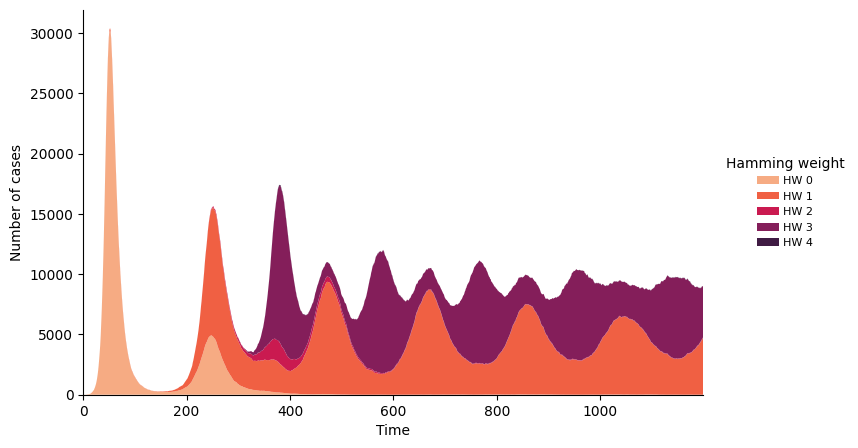

teeplots/2026-05-20-founder/a=hamming-weight+n_sites=4+n_steps=1200+palette=viridis+pow=1.0+replicate=1+viz=subplots+ext=.pdf
teeplots/2026-05-20-founder/a=hamming-weight+n_sites=4+n_steps=1200+palette=viridis+pow=1.0+replicate=1+viz=subplots+ext=.png


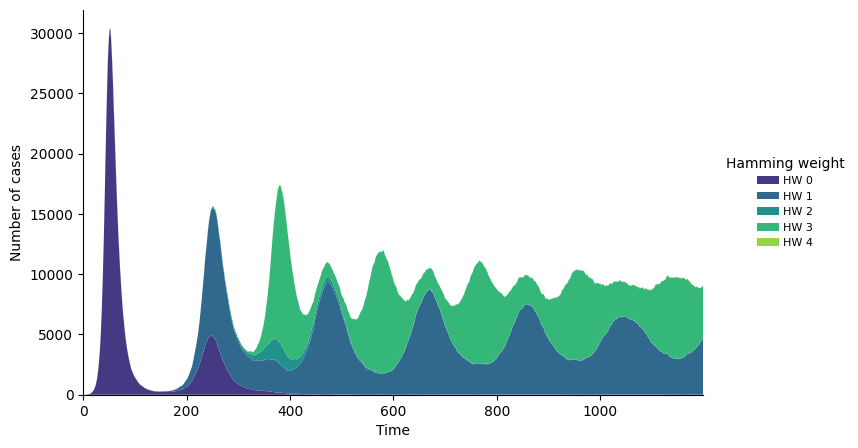

teeplots/2026-05-20-founder/a=hamming-weight+n_sites=4+n_steps=1200+palette=mako+pow=1.0+replicate=1+viz=subplots+ext=.pdf
teeplots/2026-05-20-founder/a=hamming-weight+n_sites=4+n_steps=1200+palette=mako+pow=1.0+replicate=1+viz=subplots+ext=.png


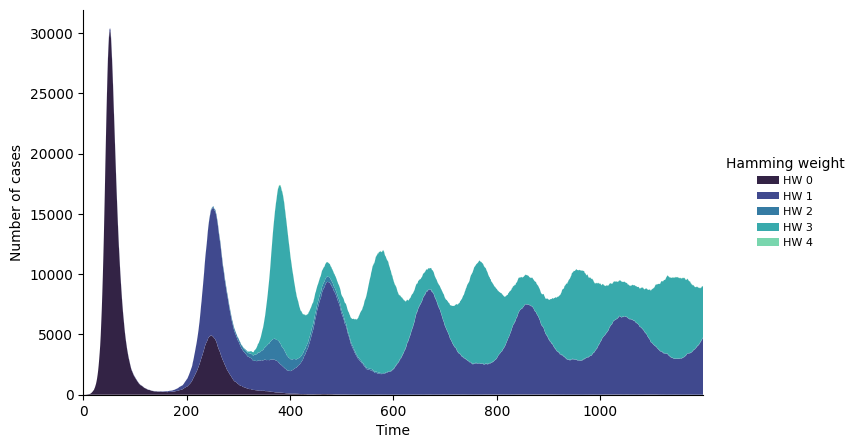

teeplots/2026-05-20-founder/a=strain-curves+n_sites=4+n_steps=1200+palette=husl+pow=1.0+replicate=1+viz=subplots+ext=.pdf
teeplots/2026-05-20-founder/a=strain-curves+n_sites=4+n_steps=1200+palette=husl+pow=1.0+replicate=1+viz=subplots+ext=.png


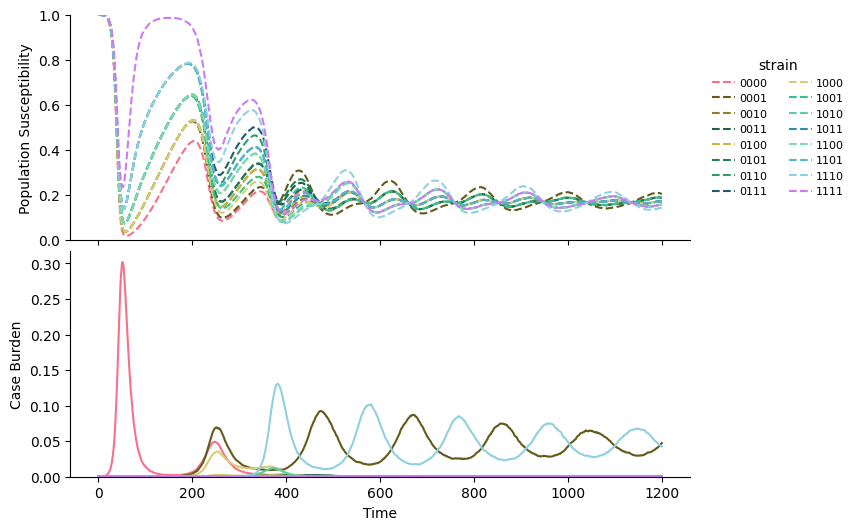

teeplots/2026-05-20-founder/a=allele-curves+n_sites=4+n_steps=1200+palette=husl+pow=1.0+replicate=1+viz=subplots+ext=.pdf
teeplots/2026-05-20-founder/a=allele-curves+n_sites=4+n_steps=1200+palette=husl+pow=1.0+replicate=1+viz=subplots+ext=.png


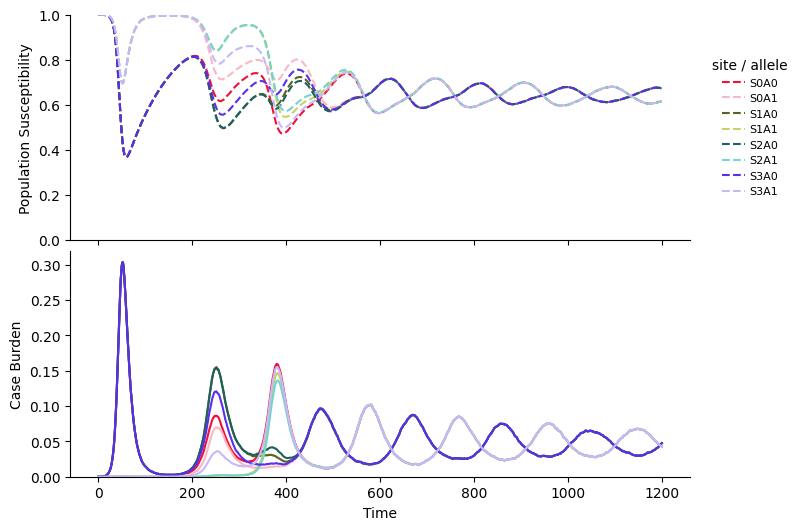

teeplots/2026-05-20-founder/a=r-curves+n_sites=4+n_steps=1200+palette=husl+pow=1.0+replicate=1+viz=subplots+ext=.pdf
teeplots/2026-05-20-founder/a=r-curves+n_sites=4+n_steps=1200+palette=husl+pow=1.0+replicate=1+viz=subplots+ext=.png


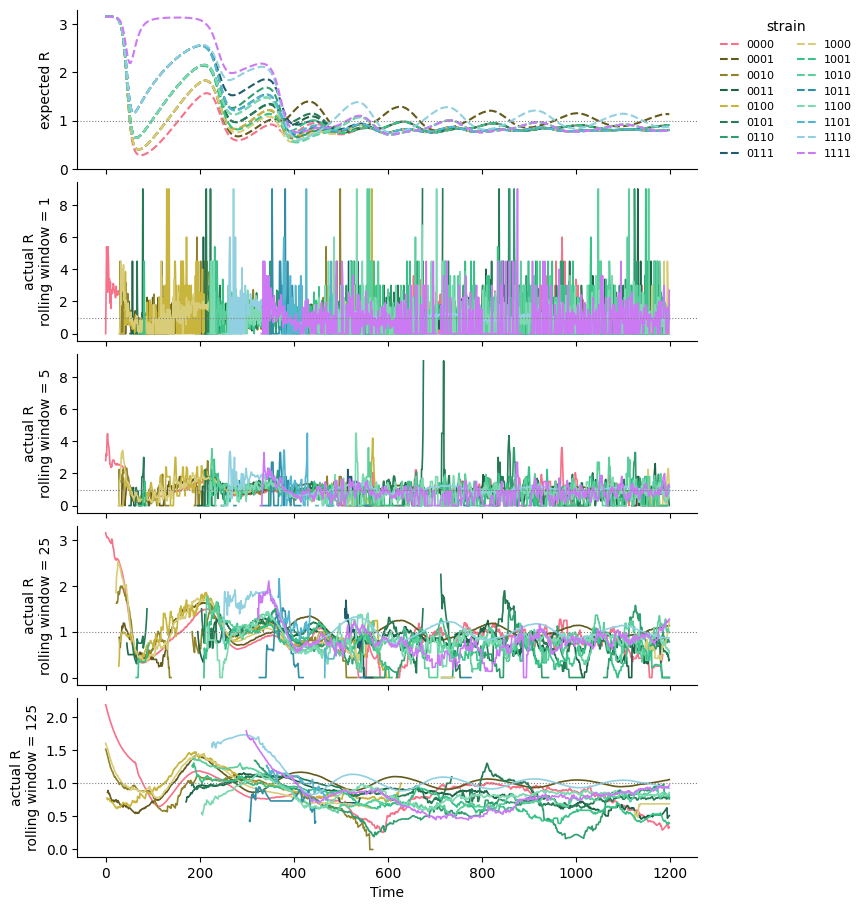

teeplots/2026-05-20-founder/a=strain-summary+n_sites=4+n_steps=1200+palette=husl+pow=1.0+replicate=1+viz=subplots+ext=.pdf
teeplots/2026-05-20-founder/a=strain-summary+n_sites=4+n_steps=1200+palette=husl+pow=1.0+replicate=1+viz=subplots+ext=.png


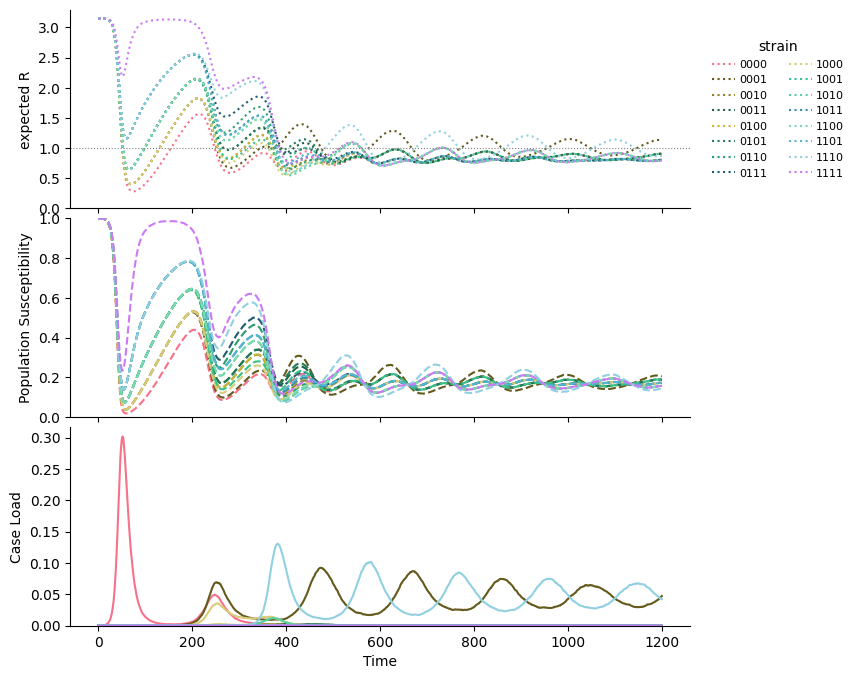

teeplots/2026-05-20-founder/a=strain-curves+n_sites=4+n_steps=1200+palette=hls+pow=1.0+replicate=1+viz=subplots+ext=.pdf
teeplots/2026-05-20-founder/a=strain-curves+n_sites=4+n_steps=1200+palette=hls+pow=1.0+replicate=1+viz=subplots+ext=.png


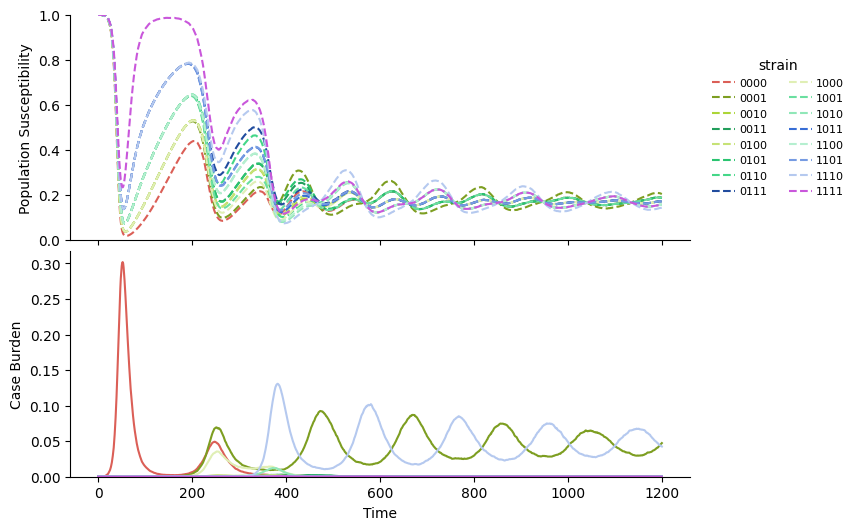

teeplots/2026-05-20-founder/a=allele-curves+n_sites=4+n_steps=1200+palette=hls+pow=1.0+replicate=1+viz=subplots+ext=.pdf
teeplots/2026-05-20-founder/a=allele-curves+n_sites=4+n_steps=1200+palette=hls+pow=1.0+replicate=1+viz=subplots+ext=.png


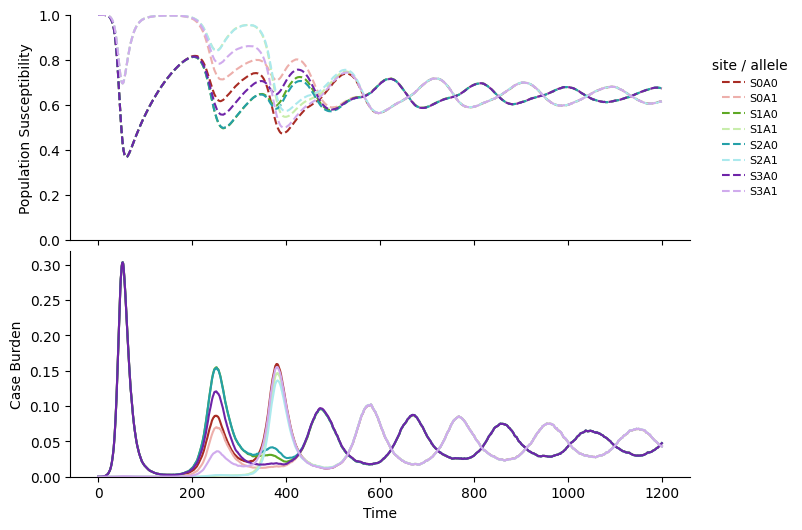

teeplots/2026-05-20-founder/a=r-curves+n_sites=4+n_steps=1200+palette=hls+pow=1.0+replicate=1+viz=subplots+ext=.pdf
teeplots/2026-05-20-founder/a=r-curves+n_sites=4+n_steps=1200+palette=hls+pow=1.0+replicate=1+viz=subplots+ext=.png


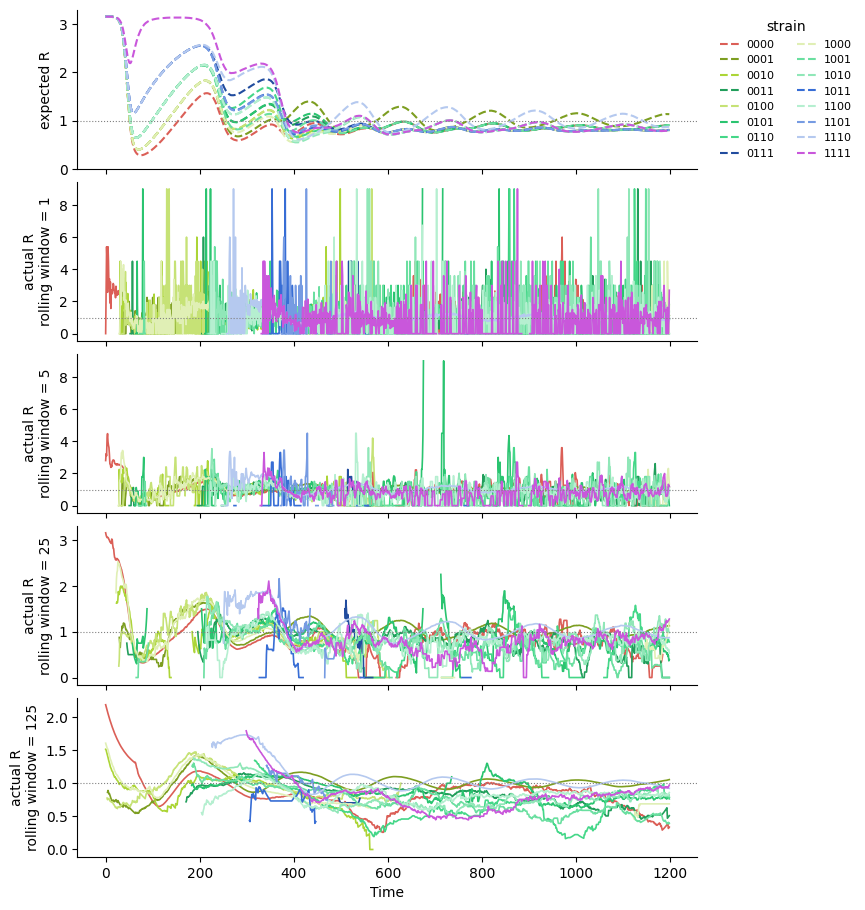

teeplots/2026-05-20-founder/a=strain-summary+n_sites=4+n_steps=1200+palette=hls+pow=1.0+replicate=1+viz=subplots+ext=.pdf
teeplots/2026-05-20-founder/a=strain-summary+n_sites=4+n_steps=1200+palette=hls+pow=1.0+replicate=1+viz=subplots+ext=.png


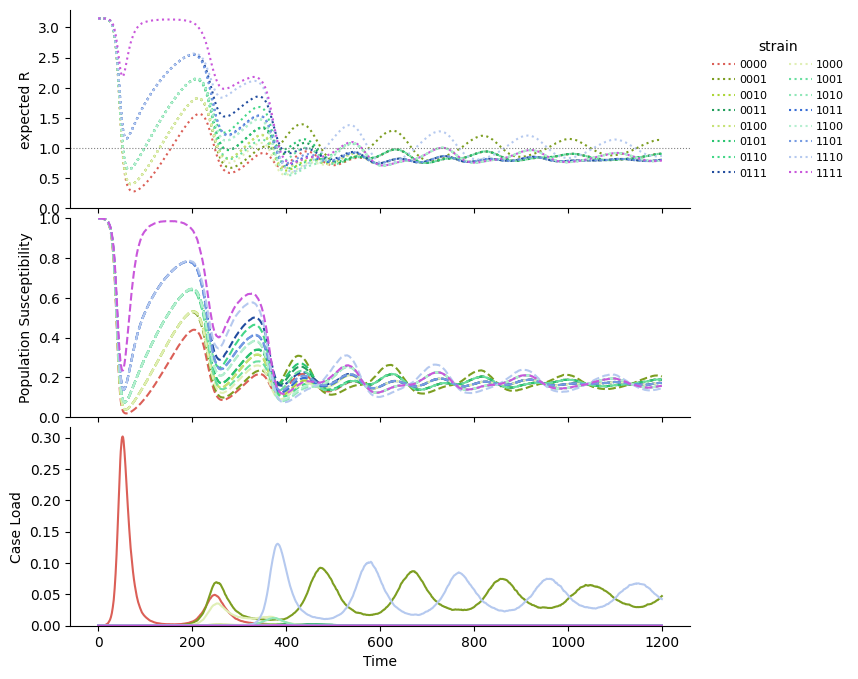

teeplots/2026-05-20-founder/a=strain-curves+n_sites=4+n_steps=1200+palette=Set2+pow=1.0+replicate=1+viz=subplots+ext=.pdf
teeplots/2026-05-20-founder/a=strain-curves+n_sites=4+n_steps=1200+palette=Set2+pow=1.0+replicate=1+viz=subplots+ext=.png


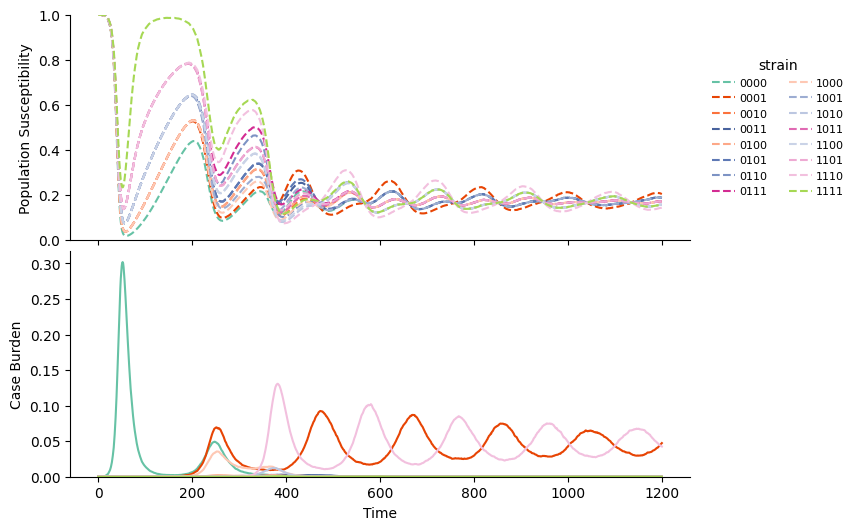

teeplots/2026-05-20-founder/a=allele-curves+n_sites=4+n_steps=1200+palette=Set2+pow=1.0+replicate=1+viz=subplots+ext=.pdf
teeplots/2026-05-20-founder/a=allele-curves+n_sites=4+n_steps=1200+palette=Set2+pow=1.0+replicate=1+viz=subplots+ext=.png


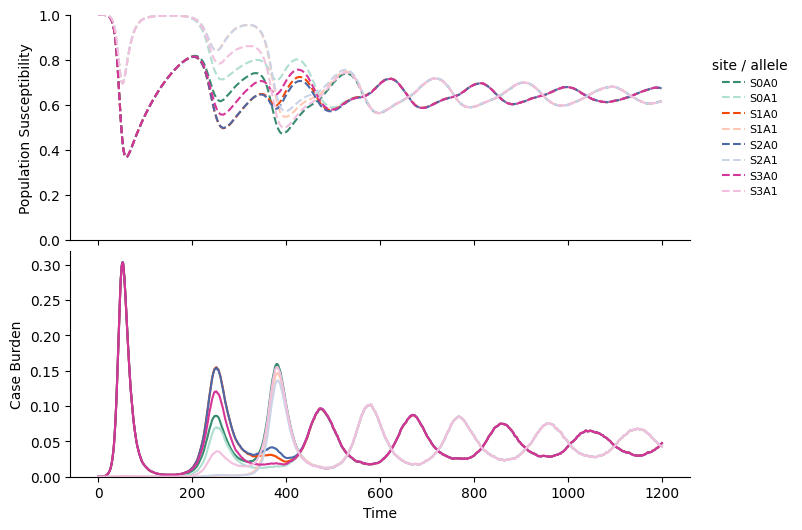

teeplots/2026-05-20-founder/a=r-curves+n_sites=4+n_steps=1200+palette=Set2+pow=1.0+replicate=1+viz=subplots+ext=.pdf
teeplots/2026-05-20-founder/a=r-curves+n_sites=4+n_steps=1200+palette=Set2+pow=1.0+replicate=1+viz=subplots+ext=.png


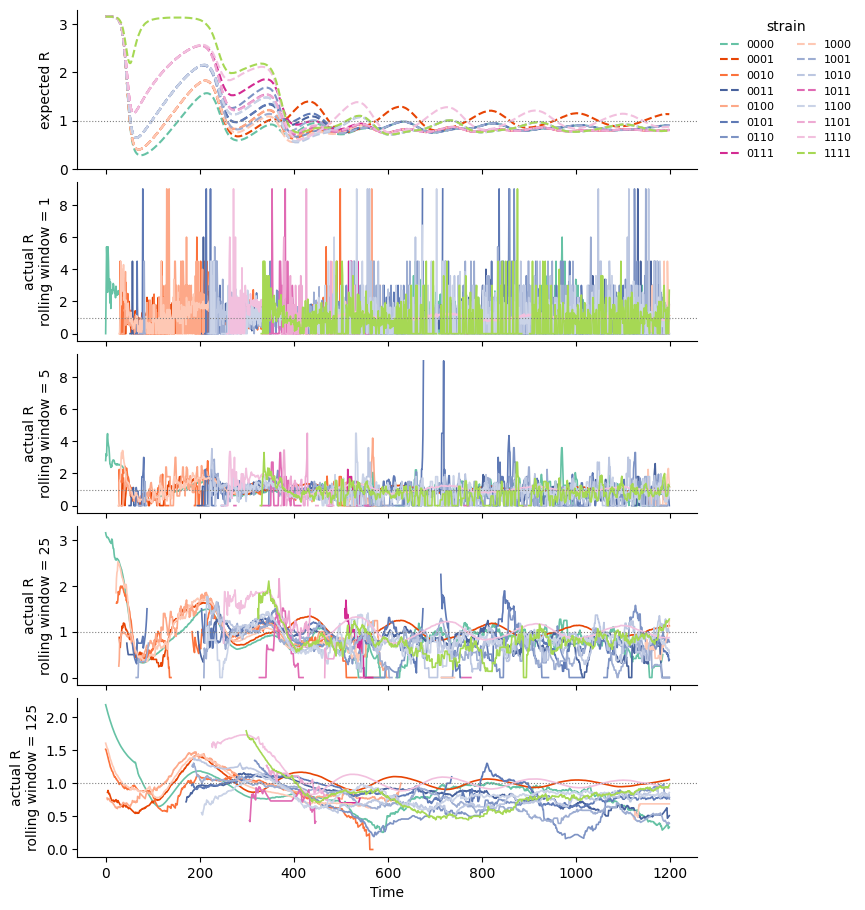

teeplots/2026-05-20-founder/a=strain-summary+n_sites=4+n_steps=1200+palette=Set2+pow=1.0+replicate=1+viz=subplots+ext=.pdf
teeplots/2026-05-20-founder/a=strain-summary+n_sites=4+n_steps=1200+palette=Set2+pow=1.0+replicate=1+viz=subplots+ext=.png


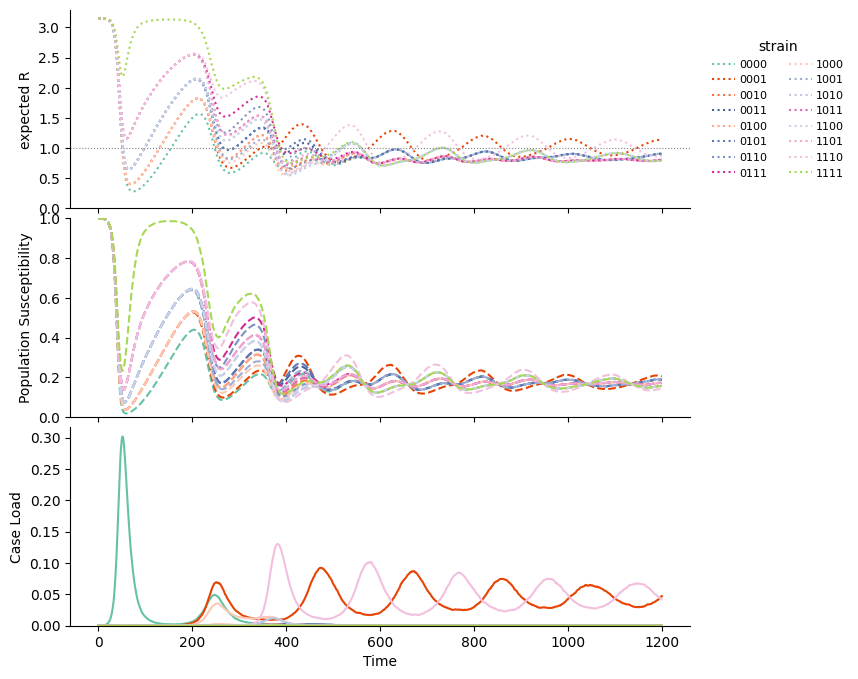

teeplots/2026-05-20-founder/a=density-heatmap+cmap=rocket+n_sites=4+n_steps=1200+pow=1.0+replicate=1+viz=subplots+ext=.pdf
teeplots/2026-05-20-founder/a=density-heatmap+cmap=rocket+n_sites=4+n_steps=1200+pow=1.0+replicate=1+viz=subplots+ext=.png


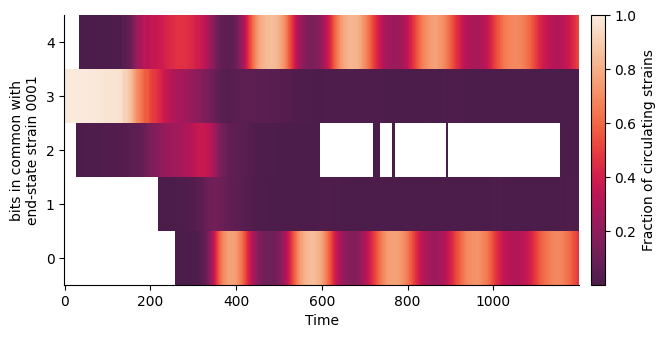

teeplots/2026-05-20-founder/a=density-heatmap+cmap=viridis+n_sites=4+n_steps=1200+pow=1.0+replicate=1+viz=subplots+ext=.pdf
teeplots/2026-05-20-founder/a=density-heatmap+cmap=viridis+n_sites=4+n_steps=1200+pow=1.0+replicate=1+viz=subplots+ext=.png


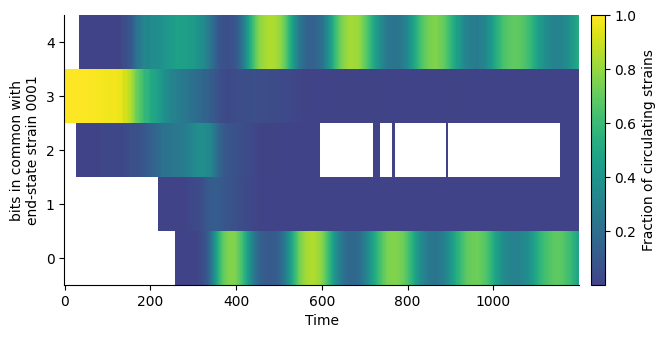

teeplots/2026-05-20-founder/a=density-heatmap+cmap=magma+n_sites=4+n_steps=1200+pow=1.0+replicate=1+viz=subplots+ext=.pdf
teeplots/2026-05-20-founder/a=density-heatmap+cmap=magma+n_sites=4+n_steps=1200+pow=1.0+replicate=1+viz=subplots+ext=.png


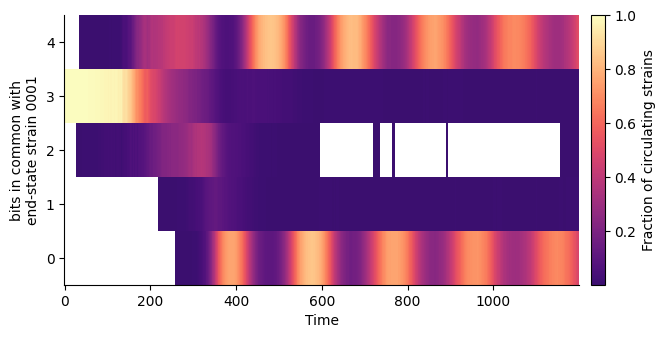

  extant rows: 200
teeplots/2026-05-20-founder/a=strain-graph+n_sites=4+n_steps=1200+palette=rocket_r+pow=1.0+replicate=1+viz=subplots+ext=.pdf
teeplots/2026-05-20-founder/a=strain-graph+n_sites=4+n_steps=1200+palette=rocket_r+pow=1.0+replicate=1+viz=subplots+ext=.png


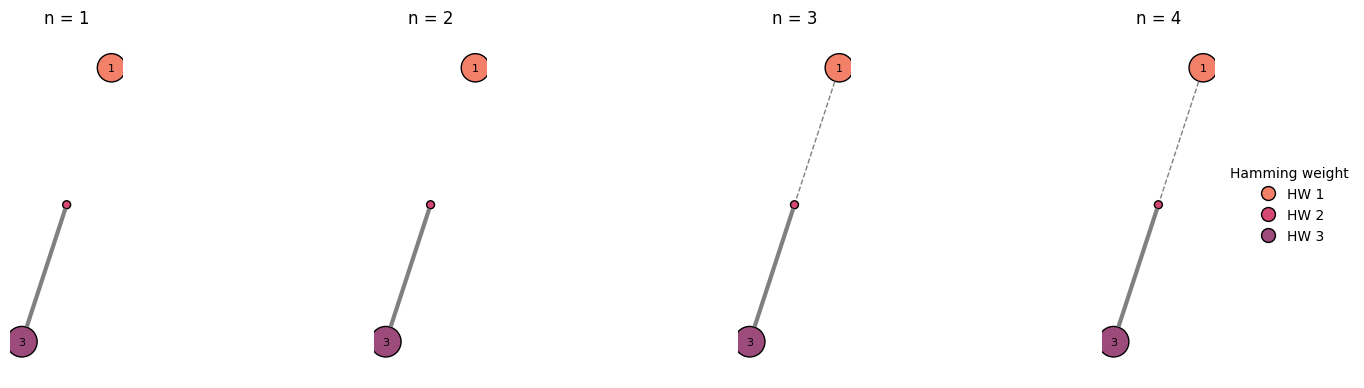

teeplots/2026-05-20-founder/a=strain-graph+n_sites=4+n_steps=1200+palette=tab20+pow=1.0+replicate=1+viz=subplots+ext=.pdf
teeplots/2026-05-20-founder/a=strain-graph+n_sites=4+n_steps=1200+palette=tab20+pow=1.0+replicate=1+viz=subplots+ext=.png


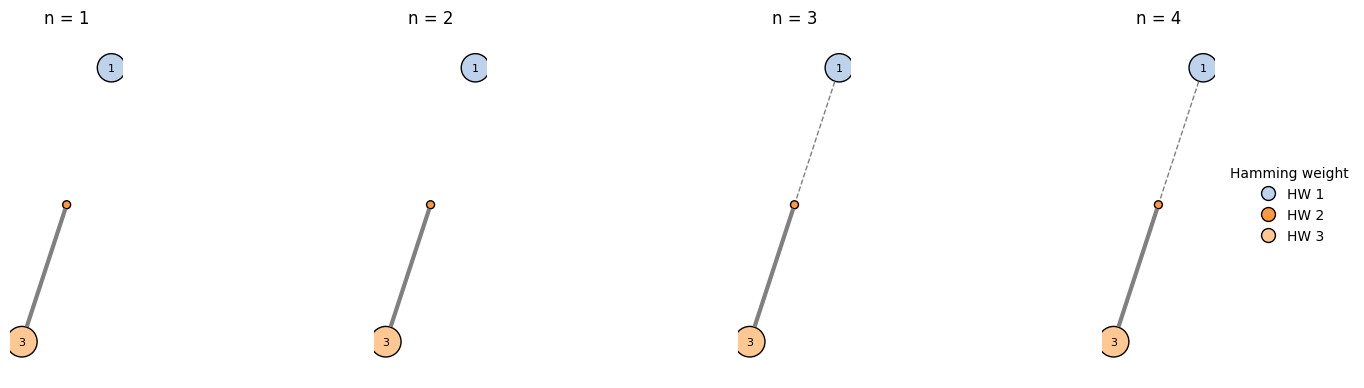

teeplots/2026-05-20-founder/a=strain-graph+n_sites=4+n_steps=1200+palette=tab10+pow=1.0+replicate=1+viz=subplots+ext=.pdf
teeplots/2026-05-20-founder/a=strain-graph+n_sites=4+n_steps=1200+palette=tab10+pow=1.0+replicate=1+viz=subplots+ext=.png


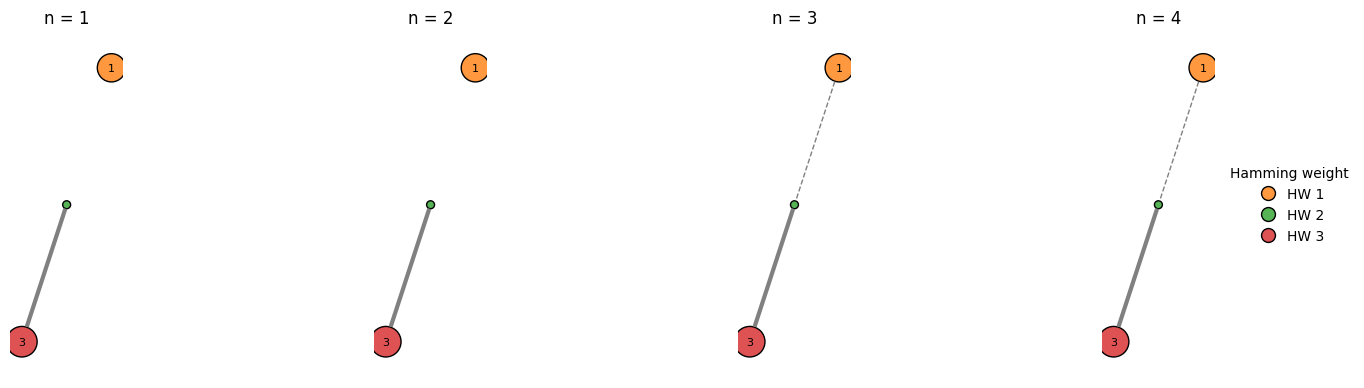

/usr/local/lib/python3.10/dist-packages/alifedata_phyloinformatics_convert/_impl/phytrack_Systematcs.py:7: UserWarning: ImportWarning: phylotrackpy.Systematics import failed; inserting a no-op mock for Systematics. This is likely because phylotrackpy is not installed.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/alifedata_phyloinformatics_convert/_impl/phytrack_Systematcs.py:7: UserWarning: ImportWarning: phylotrackpy.Systematics import failed; inserting a no-op mock for Systematics. This is likely because phylotrackpy is not installed.
  warnings.warn(
2026-06-25 02:14:02 INFO     - worker collecting slice(0, 1000000, None)
2026-06-25 02:14:02 INFO     - worker exploding slice(0, 1000000, None)
2026-06-25 02:14:02 INFO     enter log_context_duration for dstream.dataframe.explode_lookup_unpacked (slice(0, 1000000, None))
/usr/local/lib/python3.10/dist-packages/downstream/dataframe/_impl/_check_downstream_version.py:34: UserWarning: Dataframe downstream_version column not pr

  reconstructed: 400 nodes
  extant tips: 200
  wrote phylo parquet (400 rows): outdata/2026-05-20-founder/phylo/95858cce403d440fb02ea43dd1450186/a=phylo+what=2026-05-20-founder+ext=.pqt
  downsampled tree: 400 nodes
  leaf count: 200
teeplots/2026-05-20-founder/method=hstrat-surface+n_sites=4+n_steps=1200+palette=rocket_r+pow=1.0+replicate=1+viz=subplots+ext=.pdf
teeplots/2026-05-20-founder/method=hstrat-surface+n_sites=4+n_steps=1200+palette=rocket_r+pow=1.0+replicate=1+viz=subplots+ext=.png


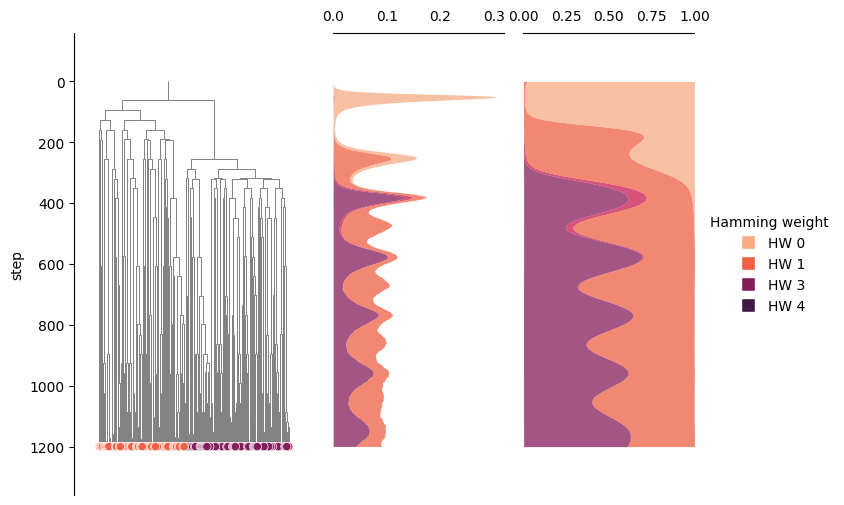

  downsampled tree: 400 nodes
  leaf count: 200
teeplots/2026-05-20-founder/method=hstrat-surface+n_sites=4+n_steps=1200+palette=tab20+pow=1.0+replicate=1+viz=subplots+ext=.pdf
teeplots/2026-05-20-founder/method=hstrat-surface+n_sites=4+n_steps=1200+palette=tab20+pow=1.0+replicate=1+viz=subplots+ext=.png


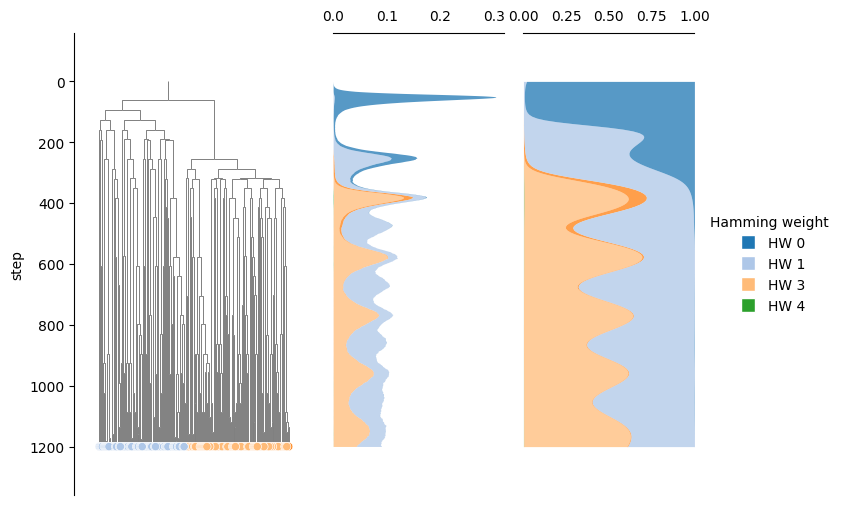

  downsampled tree: 400 nodes
  leaf count: 200
teeplots/2026-05-20-founder/method=hstrat-surface+n_sites=4+n_steps=1200+palette=tab10+pow=1.0+replicate=1+viz=subplots+ext=.pdf
teeplots/2026-05-20-founder/method=hstrat-surface+n_sites=4+n_steps=1200+palette=tab10+pow=1.0+replicate=1+viz=subplots+ext=.png


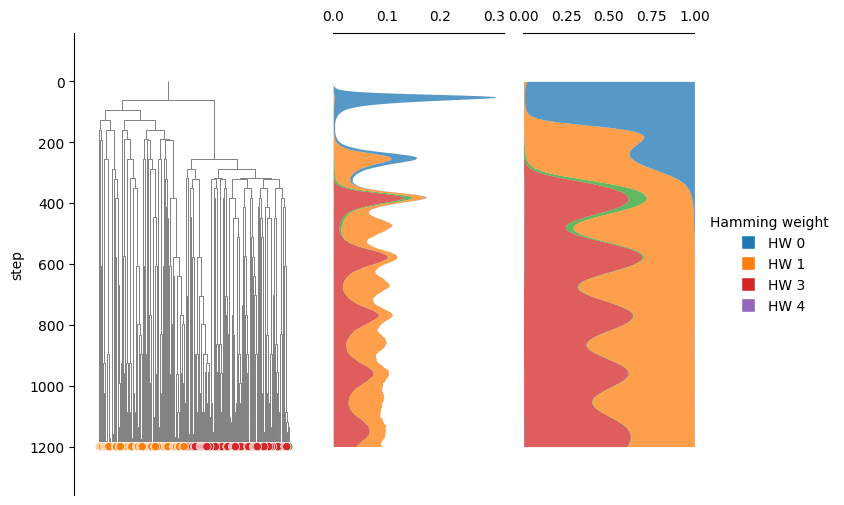

founder run complete: uid=95858cce403d440fb02ea43dd1450186


In [ ]:
# Fixed epidemiological parameters (not exposed on the command
# line); these mirror the settings used by the parent sweep
# notebook 2026-05-06-allele-abm-r-per-strain.py. MUTATION_RATE is
# the exception --- it is supplied via --mutation-rate (default
# 1e-5) so it can be swept on the command line.
CONTACT_RATE = 0.35
RECOVERY_RATE = 0.1
WANING_RATE = 0.01
IMMUNE_STRENGTH = 0.7
SEED_COUNT = 2
IMMUNITY_FLOOR = 0.05
IMMUNITY_CEILING = 1.0

n_strains = 1 << N_SITES
# Per-strain figures draw one line/node per strain (or build an
# n_strains x n_strains adjacency matrix); gate them off above 16
# strains so the aggregate figures (Hamming weight, density
# heatmap) still render at large N_SITES.
do_per_strain_plots = n_strains <= 16

# Replicate UUID (standard-library uuid) --- uniquely identifies
# the rows produced by this run across invocations and seeds.
replicate_uid = uuid.uuid4().hex
print(
    f"=== founder run: seed={SEED} N_SITES={N_SITES} "
    f"pop_size={POP_SIZE} n_steps={N_STEPS} engine={ENGINE} "
    f"uid={replicate_uid} ===",
)

traj_df, hw_df, strain_df, records_df = simulate(
    MUTATION_RATE=MUTATION_RATE,
    N_SITES=N_SITES,
    N_STEPS=N_STEPS,
    POP_SIZE=POP_SIZE,
    CONTACT_RATE=CONTACT_RATE,
    RECOVERY_RATE=RECOVERY_RATE,
    WANING_RATE=WANING_RATE,
    IMMUNE_STRENGTH=IMMUNE_STRENGTH,
    SEED_COUNT=SEED_COUNT,
    IMMUNITY_FLOOR=IMMUNITY_FLOOR,
    IMMUNITY_CEILING=IMMUNITY_CEILING,
    seed=SEED,
    track_phylogeny=True,
    N_SAMPLE=200,
    pow=POW,
)
print(f"  snapshot rows: {len(records_df)}")

# Simulation parameters recorded as constant-valued columns so each
# output dataframe is self-describing --- e.g. every row carries the
# population size it was produced under --- plus the replicate UUID.
params = {
    "replicate_uid": replicate_uid,
    "seed": SEED,
    "n_sites": N_SITES,
    "pop_size": POP_SIZE,
    "n_steps": N_STEPS,
    "engine": ENGINE,
    "pow": POW,
    "mutation_rate": MUTATION_RATE,
    "contact_rate": CONTACT_RATE,
    "recovery_rate": RECOVERY_RATE,
    "waning_rate": WANING_RATE,
    "immune_strength": IMMUNE_STRENGTH,
    "seed_count": SEED_COUNT,
    "immunity_floor": IMMUNITY_FLOOR,
    "immunity_ceiling": IMMUNITY_CEILING,
}

nbname = pathlib.Path(__file__).stem
out_dir = pathlib.Path("outdata") / nbname
out_dir.mkdir(parents=True, exist_ok=True)

def _save(kind, df):
    rep_dir = out_dir / kind / replicate_uid
    rep_dir.mkdir(parents=True, exist_ok=True)
    rep_path = rep_dir / f"a={kind}+what={nbname}+ext=.pqt"
    df.to_parquet(rep_path, index=False)
    print(f"  wrote {kind} parquet ({len(df)} rows): {rep_path}")

_save("traj", traj_df.assign(**params))
_save("hw", hw_df.assign(**params))
_save("strain", strain_df.assign(**params))
_save("records", records_df.assign(**params))

teeplot_base = {
    "n_sites": N_SITES,
    "n_steps": int(traj_df["Step"].max()) + 1,
    "replicate": SEED,
    "pow": POW,
}

if SKIP_PLOTTING:
    print("  (SKIP_PLOTTING=True --- skipping all figures)")
else:
    for _palette in "rocket_r", "viridis", "mako":
        make_hamming_weight_plot(
            N_SITES,
            hw_df,
            palette=_palette,
            teeplot_outattrs={
                **teeplot_base,
                "a": "hamming-weight",
                "palette": _palette,
            },
        )
    for _palette in "husl", "hls", "Set2":
        if do_per_strain_plots:
            make_strain_curves_plot(
                N_SITES,
                traj_df,
                strain_df,
                palette=_palette,
                teeplot_outattrs={
                    **teeplot_base,
                    "a": "strain-curves",
                    "palette": _palette,
                },
            )
        make_allele_curves_plot(
            N_SITES,
            traj_df,
            strain_df,
            palette=_palette,
            teeplot_outattrs={
                **teeplot_base,
                "a": "allele-curves",
                "palette": _palette,
            },
        )
        if do_per_strain_plots:
            make_r_curves_plot(
                N_SITES,
                strain_df,
                RECOVERY_RATE=RECOVERY_RATE,
                palette=_palette,
                teeplot_outattrs={
                    **teeplot_base,
                    "a": "r-curves",
                    "palette": _palette,
                },
            )
            make_strain_summary_plot(
                N_SITES,
                traj_df,
                strain_df,
                RECOVERY_RATE=RECOVERY_RATE,
                palette=_palette,
                teeplot_outattrs={
                    **teeplot_base,
                    "a": "strain-summary",
                    "palette": _palette,
                },
            )
    for _cmap in "rocket", "viridis", "magma":
        make_density_heatmap_plot(
            N_SITES,
            strain_df,
            cmap=_cmap,
            teeplot_outattrs={
                **teeplot_base,
                "a": "density-heatmap",
                "cmap": _cmap,
            },
        )

if len(records_df) == 0:
    print("  (no infected hosts --- skipping phylogeny reconstruction)")
else:
    print(f"  extant rows: {int(records_df['extant'].sum())}")
    if not SKIP_PLOTTING and not do_per_strain_plots:
        print("  (n_strains too large --- skipping strain graph)")
    elif not SKIP_PLOTTING:
        for _palette in "rocket_r", "tab20", "tab10":
            make_strain_graph_plot(
                N_SITES,
                records_df,
                max_n=4,
                palette=_palette,
                teeplot_outattrs={
                    **teeplot_base,
                    "a": "strain-graph",
                    "palette": _palette,
                },
            )

    phylogeny_df = reconstruct_phylogeny(records_df)
    print(f"  reconstructed: {len(phylogeny_df)} nodes")
    print(f"  extant tips: {int(phylogeny_df['extant'].sum())}")
    _save("phylo", phylogeny_df.assign(**params))

    if not SKIP_PLOTTING:
        for _palette in "rocket_r", "tab20", "tab10":
            make_phylogeny_plot(
                N_SITES,
                traj_df,
                hw_df,
                phylogeny_df,
                seed=SEED,
                palette=_palette,
                teeplot_outattrs={
                    **teeplot_base,
                    "method": "hstrat-surface",
                    "palette": _palette,
                },
            )

print(f"founder run complete: uid={replicate_uid}")